# Experiment 03 — PdO on HfO₂: initial Sobol design

This notebook generates the **first** space-filling Sobol design for **PdO on HfO₂**.
Unlike `experiment02_pdo_analysis.ipynb` (PdO on Al₂O₃, a *post-experiment* analysis of a
completed delivery), there is **no experimental data yet** — we are at the design-creation
stage. The goal here is only to produce a fabrication-ready DoE and check its space-filling
quality.

**Why HfO₂ changes the bounds.** PdO on HfO₂ decomposes at ≥ ~510 °C (vs ~695 °C on Al₂O₃),
so to prevent decomposition we cap **both** the oxidation and vacuum-annealing temperatures
below 500 °C. We also pin deposition temperature at 425 °C and only sweep oxidation pressure
over the two practical setpoints {0.01, 0.02} atm.

**Sobol factors (9 swept + 1 pinned):**

| Factor | Range | Step |
|---|---|---|
| Dep Power (W) | 2 → 40 | 1 W |
| O₂ Flow (sccm) | {0} ∪ [0.3 → 20] | 0.1 sccm |
| Dep Press (mTorr) | 2 → 10 | 0.1 mTorr |
| Ox Temp (°C) | 200 → 500 | 5 °C |
| Ox Press (atm) | {0.01, 0.02} | — |
| Ox Time (min) | 0 → 120 | 1 s |
| Vac Ann Temp (°C) | 25 → 500 | 5 °C |
| Vac Ann Time (min) | 0 → 120 | 1 s |
| Dep Thickness (nm) | 2 → 6 | 0.1 nm |
| Dep Temp (°C) | **pinned at 425** | — |

Design size: **23 base runs × 3 replicates = 69 rows** (mirrors the experiment02 PdO precedent).
Outputs are saved to `repository_dmref/output/experiment03_hfo2_sobol_design/`.

In [1]:
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import qmc
from scipy.spatial.distance import pdist

warnings.filterwarnings('ignore')

# Anchor at repo root so relative paths work regardless of where Jupyter starts.
REPO_ROOT = '/data/zhq7531/IDEAL/DMREF/repository_dmref'
os.chdir(REPO_ROOT)

OUT_DIR = 'output/experiment03_hfo2_sobol_design'
os.makedirs(OUT_DIR, exist_ok=True)

sns.set_theme(style='whitegrid')
print('Working dir:', os.getcwd())
print('Outputs  ->', OUT_DIR)

Working dir: /data/zhq7531/IDEAL/DMREF/repository_dmref
Outputs  -> output/experiment03_hfo2_sobol_design


## 1. Factor configuration and Sobol generator

The generator is the same low-discrepancy machinery used for the PdO-on-Al₂O₃ design, with two
small extensions baked into `map_parameter`:

* a **`step`** field that snaps each mapped value onto the tool's resolution grid (e.g. 5 °C,
  1 s, 0.1 nm) instead of rounding to a fixed number of decimals; and
* a **gap** option (`gap_prob` / `gap_val`) so the O₂ flow can land on the discrete *0 sccm*
  ("no flow") setpoint as well as the continuous 0.3–20 sccm range.

`Dep Temp (°C)` is **not** a Sobol dimension — it is appended afterward as a constant 425 °C
column, so all 9 swept factors keep their full Sobol coverage.

In [2]:
GLOBAL_SEED   = 20      # same seed convention as experiment02
N_CONDITIONS  = 23      # base runs (matches PdO Batch 1)
NUM_REPLICATES = 3
DEP_TEMP_FIXED = 425.0  # pinned deposition temperature (°C), not swept

# 9 Sobol-swept factors. 'step' snaps to the tool resolution; lists are discrete levels.
HFO2_CONFIG = {
    'Dep Power (W)':      {'min': 2.0,   'max': 40.0,  'step': 1.0},     # 1 W/step
    'O2 Flow (sccm)':     {'gap_prob': 0.10, 'gap_val': 0.0,             # 0 sccm "no flow" option
                           'min': 0.3,   'max': 20.0,  'step': 0.1},     # else 0.3-20, 0.1 sccm/step
    'Dep Press (mTorr)':  {'min': 2.0,   'max': 10.0,  'step': 0.1},     # 0.1 mTorr/step
    'Ox Temp (°C)':       {'min': 200.0, 'max': 500.0, 'step': 5.0},     # 5 °C/step, capped <500 (decomp)
    'Ox Press (atm)':     [0.01, 0.02],                                  # two practical setpoints
    'Ox Time (min)':      {'min': 0.0,   'max': 120.0, 'step': 0.1},     # 0.1 min (6 s); 1 s/step over-resolves
    'Vac Ann Temp (°C)':  {'min': 25.0,  'max': 500.0, 'step': 5.0},     # 5 °C/step, capped <500 (decomp)
    'Vac Ann Time (min)': {'min': 0.0,   'max': 120.0, 'step': 0.1},     # 0.1 min (6 s); 1 s/step over-resolves
    'Dep Thickness (nm)': {'min': 2.0,   'max': 6.0,   'step': 0.1},     # 0.1 nm/step
}
FACTORS = list(HFO2_CONFIG.keys())   # 9 swept factors

def map_parameter(u_val, settings):
    """Map a unit-cube coordinate to a physical factor value, honoring step / gap / levels."""
    if isinstance(settings, list):                      # discrete levels
        idx = min(int(u_val * len(settings)), len(settings) - 1)
        return settings[idx]
    if settings.get('gap_prob', 0) > 0 and u_val < settings['gap_prob']:
        return settings['gap_val']                      # land on the discrete gap value
    if 'gap_prob' in settings and settings['gap_prob'] > 0:
        scaled = (u_val - settings['gap_prob']) / (1.0 - settings['gap_prob'])
        val = settings['min'] + scaled * (settings['max'] - settings['min'])
    else:
        val = settings['min'] + u_val * (settings['max'] - settings['min'])
    if 'step' in settings:                              # snap to the tool resolution grid
        return round(round(val / settings['step']) * settings['step'], 6)
    return round(val, settings.get('decimals', 1))

def generate_doe(num_samples, config, sampler=None, seed=None):
    names = list(config.keys())
    if sampler is None:
        sampler = qmc.Sobol(d=len(names), scramble=True, seed=seed)
    rows = []
    while len(rows) < num_samples:
        batch = sampler.random(n=num_samples * 5)
        for u in batch:
            rows.append([map_parameter(u[i], config[n]) for i, n in enumerate(names)])
            if len(rows) == num_samples:
                break
    return pd.DataFrame(rows, columns=names), sampler

def add_replicates(df, k):
    df = df.copy()
    df.insert(0, 'Base_Run_ID', range(1, len(df) + 1))
    df = df.loc[df.index.repeat(k)].reset_index(drop=True)
    df.insert(1, 'Replicate', df.groupby('Base_Run_ID').cumcount() + 1)
    return df

# Generate the HfO2 Sobol plan
df_plan, sampler = generate_doe(N_CONDITIONS, HFO2_CONFIG, seed=GLOBAL_SEED)
df_plan.insert(len(df_plan.columns) - 0, 'Dep Temp (°C)', DEP_TEMP_FIXED)  # pinned column
df_plan['Batch'] = 'Batch 1'
df_full = add_replicates(df_plan, NUM_REPLICATES)
print(f'HfO2 Sobol plan: {N_CONDITIONS} conditions x {NUM_REPLICATES} replicates = {df_full.shape[0]} rows')
df_plan

HfO2 Sobol plan: 23 conditions x 3 replicates = 69 rows


,Dep Power (W),O2 Flow (sccm),Dep Press (mTorr),Ox Temp (°C),Ox Press (atm),Ox Time (min),Vac Ann Temp (°C),Vac Ann Time (min),Dep Thickness (nm),Dep Temp (°C),Batch
0,5.0,2.6,4.3,440.0,0.02,97.8,415.0,86.6,5.0,425.0,Batch 1
1,22.0,17.8,8.7,200.0,0.01,58.3,125.0,53.2,2.8,425.0,Batch 1
2,35.0,8.4,2.8,375.0,0.01,15.7,365.0,26.7,3.5,425.0,Batch 1
3,19.0,12.3,6.1,310.0,0.02,66.2,175.0,112.9,4.7,425.0,Batch 1
4,14.0,5.4,9.3,345.0,0.02,114.0,270.0,14.7,3.5,425.0,Batch 1
5,31.0,9.7,5.7,415.0,0.01,45.0,215.0,100.6,4.3,425.0,Batch 1
6,27.0,0.0,7.8,245.0,0.01,1.0,450.0,74.5,6.0,425.0,Batch 1
7,10.0,14.9,3.2,475.0,0.02,82.0,25.0,40.8,2.2,425.0,Batch 1
8,8.0,6.3,7.1,400.0,0.01,71.1,305.0,6.2,4.0,425.0,Batch 1
9,30.0,13.4,3.9,320.0,0.02,27.8,240.0,92.3,4.2,425.0,Batch 1


## 2. Design quality — Sobol vs LHS vs optimized LHS

Two standard space-filling diagnostics on the 9 swept factors (normalized to the unit cube):

* **Discrepancy** (`qmc.discrepancy`, centered L2) — lower is a more uniform fill of the hypercube.
* **Minimum pairwise distance** — larger means no two conditions are clustered together.

We compare our **Sobol** design against three equal-size alternatives, each averaged over 20
seeds (so a single lucky/unlucky draw doesn't decide it):

* **Uniform random** — the naive baseline.
* **LHS** (`qmc.LatinHypercube`) — guarantees 1-D marginal coverage but not multi-D uniformity.
* **Optimized LHS** (`optimization="random-cd"`) — LHS post-optimized to minimize centered
  discrepancy, the usual "best" classical space-filling design.

Sobol is deterministic given its seed, so it gets a single row; the samplers get mean ± std.

In [3]:
def normalise_for_metrics(df_in, config):
    cols = [c for c in df_in.columns if c in config]
    M = df_in[cols].copy().astype(float)
    for c in cols:
        if isinstance(config[c], list):
            uniq = sorted(set(config[c]))
            M[c] = M[c].map({v: (i / (len(uniq) - 1) if len(uniq) > 1 else 0.0)
                             for i, v in enumerate(uniq)})
        else:
            lo, hi = config[c]['min'], config[c]['max']
            M[c] = (M[c] - lo) / (hi - lo) if hi > lo else 0.0
    return np.clip(M.values, 0.0, 1.0)

d, n = len(FACTORS), N_CONDITIONS
M_sobol = normalise_for_metrics(df_plan, HFO2_CONFIG)

def sampler_stats(make_points, n_rep=20):
    """Mean/std of (discrepancy, min-pairwise-dist) over n_rep seeded draws."""
    disc, md = [], []
    for s in range(n_rep):
        P = make_points(s)
        disc.append(qmc.discrepancy(P))
        md.append(pdist(P).min())
    return np.mean(disc), np.std(disc), np.mean(md), np.std(md)

generators = {
    'Uniform random': lambda s: np.random.default_rng(s).random((n, d)),
    'LHS':            lambda s: qmc.LatinHypercube(d=d, seed=s).random(n),
    'Optimized LHS (random-cd)':
                      lambda s: qmc.LatinHypercube(d=d, optimization='random-cd', seed=s).random(n),
}

rows = [{'design': 'Sobol (this design)', 'n_conditions': n,
         'discrepancy': round(float(qmc.discrepancy(M_sobol)), 5), 'discrepancy_std': 0.0,
         'min_pairwise_dist': round(float(pdist(M_sobol).min()), 4), 'min_pairwise_dist_std': 0.0}]
for name, gen in generators.items():
    md_, ds, mm, ms = sampler_stats(gen)
    rows.append({'design': name, 'n_conditions': n,
                 'discrepancy': round(float(md_), 5), 'discrepancy_std': round(float(ds), 5),
                 'min_pairwise_dist': round(float(mm), 4), 'min_pairwise_dist_std': round(float(ms), 4)})
metrics = pd.DataFrame(rows)
metrics.to_excel(os.path.join(OUT_DIR, 'hfo2_sobol_metrics.xlsx'), index=False)
print('Lower discrepancy & larger min-distance = better space-filling (samplers: mean over 20 seeds).')
metrics

Lower discrepancy & larger min-distance = better space-filling (samplers: mean over 20 seeds).


,design,n_conditions,discrepancy,discrepancy_std,min_pairwise_dist,min_pairwise_dist_std
0,Sobol (this design),23,0.32178,0.00000,0.5743,0.0000
1,Uniform random,23,0.23658,0.04185,0.5409,0.0714
2,LHS,23,0.12195,0.00746,0.5609,0.0859
3,Optimized LHS (random-cd),23,0.07139,0.00154,0.8124,0.0439


### Visual comparison

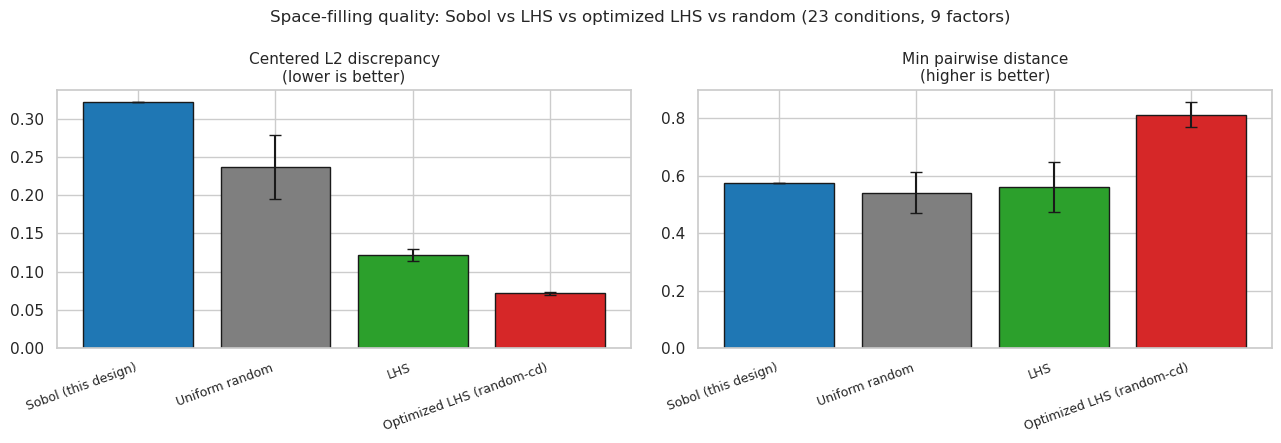

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
order = metrics['design'].tolist()
colors = ['#1f77b4', '#7f7f7f', '#2ca02c', '#d62728']
for ax, (col, std, lbl, better) in zip(axes, [
        ('discrepancy', 'discrepancy_std', 'Centered L2 discrepancy', 'lower is better'),
        ('min_pairwise_dist', 'min_pairwise_dist_std', 'Min pairwise distance', 'higher is better')]):
    ax.bar(range(len(order)), metrics[col], yerr=metrics[std], capsize=4,
           color=colors, edgecolor='k')
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, rotation=20, ha='right', fontsize=9)
    ax.set_title(f'{lbl}\n({better})', fontsize=11)
fig.suptitle('Space-filling quality: Sobol vs LHS vs optimized LHS vs random '
             f'({N_CONDITIONS} conditions, 9 factors)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'hfo2_design_quality_comparison.png'), dpi=200, bbox_inches='tight')
plt.show()

## 2.1 What do these two metrics actually measure? (a 2-D picture)

The two numbers reward different things, which is why the greedy-maximin design can be best on
one and 4× worse on the other. The 2-D demo below (16 points, easy to eyeball) makes it concrete.

**Discrepancy (centered L2) — a *global uniformity* score.** Conceptually: for every axis-aligned
sub-box of the unit square, compare the *fraction of points inside* to the *box's area*.
Discrepancy aggregates that mismatch over all sub-boxes (and over every lower-dimensional
projection). It answers **"does every region — and every factor's marginal — get its fair share
of runs?"** Lower = more evenly spread over the whole space. *This is the space-filling metric.*

**Minimum pairwise distance (maximin) — a *closest-pair* score.** It looks only at the single
nearest pair of points and measures how far apart they are. It answers **"are any two runs nearly
redundant / on top of each other?"** Higher = no clustering. But it is *blind to empty regions* —
you can leave a big hole in the middle and still have a large minimum distance.

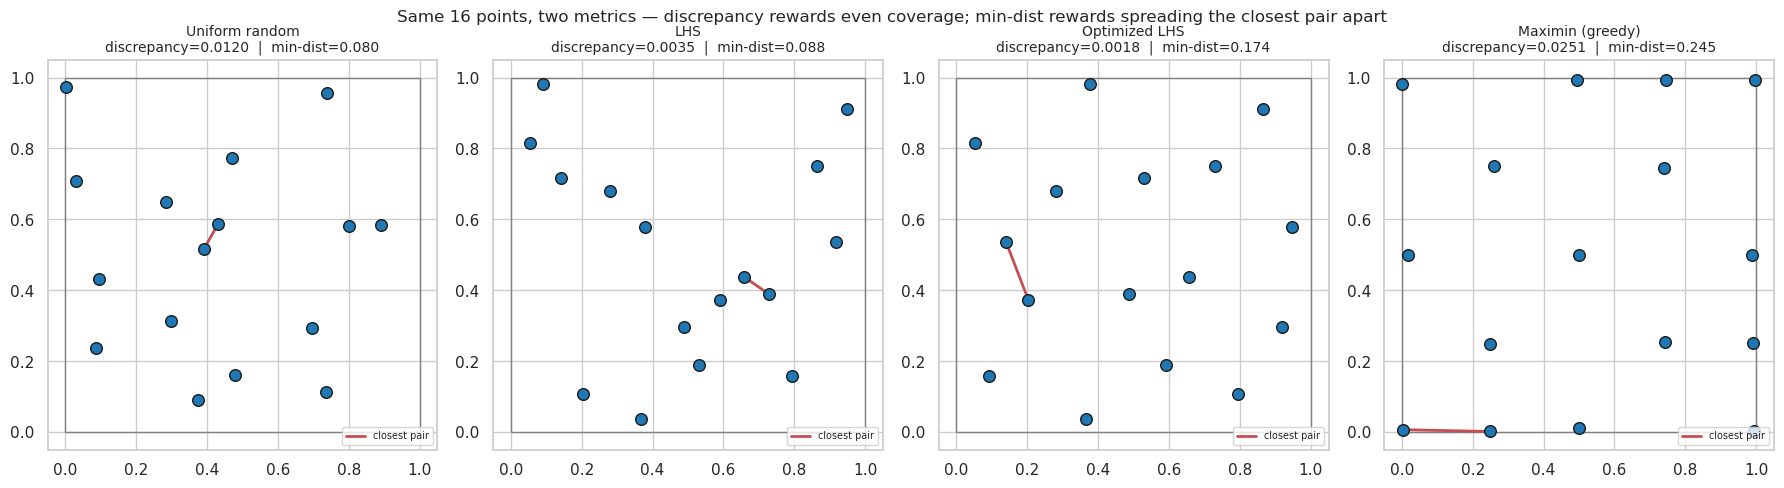

In [5]:
from scipy.spatial.distance import cdist as _cdist
np.random.seed(0)
n_demo = 16
rng_d = np.random.default_rng(3)

P_rand = rng_d.random((n_demo, 2))
P_lhs  = qmc.LatinHypercube(d=2, seed=1).random(n_demo)
P_olhs = qmc.LatinHypercube(d=2, optimization='random-cd', seed=1).random(n_demo)
# greedy maximin: each new point maximizes its min-distance to all chosen points
_chosen = [np.array([0.5, 0.5])]
for _ in range(n_demo - 1):
    c = rng_d.random((4000, 2))
    _chosen.append(c[_cdist(c, np.array(_chosen)).min(axis=1).argmax()])
P_mm = np.array(_chosen)

demos = [('Uniform random', P_rand), ('LHS', P_lhs),
         ('Optimized LHS', P_olhs), ('Maximin (greedy)', P_mm)]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.7))
for ax, (name, P) in zip(axes, demos):
    disc_v = qmc.discrepancy(P)
    # find and highlight the closest pair (what min-dist measures)
    D = _cdist(P, P); np.fill_diagonal(D, np.inf)
    i, j = np.unravel_index(D.argmin(), D.shape); md_v = D[i, j]
    ax.scatter(P[:, 0], P[:, 1], s=70, color='#1f77b4', edgecolor='k', zorder=3)
    ax.plot(P[[i, j], 0], P[[i, j], 1], 'r-', lw=2, zorder=2, label='closest pair')
    ax.add_patch(plt.Rectangle((0, 0), 1, 1, fill=False, ec='gray'))
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05); ax.set_aspect('equal')
    ax.set_title(f'{name}\ndiscrepancy={disc_v:.4f}  |  min-dist={md_v:.3f}', fontsize=10)
    ax.legend(loc='lower right', fontsize=7)
fig.suptitle('Same 16 points, two metrics — discrepancy rewards even coverage; '
             'min-dist rewards spreading the closest pair apart', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'metric_meaning_2d_demo.png'), dpi=200, bbox_inches='tight')
plt.show()

**What the picture shows.** *Optimized LHS* spreads points evenly across the square and across
both axes → **low discrepancy**, with a respectable closest-pair gap. *Maximin* pushes points
toward the **edges and corners** (like same-charge particles repelling to the walls): this gives
the **largest closest-pair distance**, but it leaves the interior and the marginal projections
unevenly covered → **high discrepancy**. That edge-loading is exactly why the greedy-maximin
second batch scored ~4× worse on cumulative discrepancy while winning min-distance.

**Is one more important?** For a space-filling DoE whose job is to **explore the response and fit
a surrogate across the whole domain, discrepancy is the primary metric** — you want every region
and every factor-projection represented, no blind spots. Minimum distance is a **secondary
guard**: it stops you from wasting runs on near-duplicates and, for a second batch, from placing a
new run on top of an already-fabricated one. The right move is therefore to **optimize coverage
(low discrepancy) subject to a minimum-distance constraint**, rather than maximizing min-distance
outright — which is essentially what *optimized LHS* already does, and why it is the best
all-round choice here.

## 2.2 Adding a second batch — does Sobol's extensibility pay off?

Sobol's classic selling point is **incremental extension**: continue the same sequence and the
cumulative point set stays low-discrepancy, whereas a fresh LHS would ignore the existing points.
But that advantage is *asymptotic* — at this DoE's scale it may not materialize. Here we simulate
the realistic second-batch scenario: **batch 1 is already fabricated (fixed)**, and we add a
second `N_CONDITIONS`-run batch, then measure the **cumulative** quality of all `2·N` points.

Strategies compared:

* **Sobol, continue sequence** — the intended Sobol workflow (what experiment02 did for its Batch 2).
* **oLHS + independent oLHS** — batch 2 is a fresh optimized LHS with no knowledge of batch 1.
* **oLHS + greedy-maximin (max min-dist)** — batch 2 greedily places each point to maximize its
  minimum distance to batch 1 + already-chosen points. Objective = *spacing*.
* **oLHS + conditional oLHS (min discrepancy)** — batch 2 is built as an LHS and then its
  coordinates are permuted to minimize the discrepancy of the **combined** batch1+batch2 set,
  with batch 1 held fixed. Same idea as `optimization='random-cd'`, but the objective is the
  *cumulative* discrepancy instead of batch 2's standalone discrepancy. Objective = *coverage*.

All four are **actionable second-batch strategies** — batch 1 stays exactly as fabricated and we
only choose where the *new* runs go. (Re-optimizing batch 1 from scratch is not an option once it
is fabricated, so it is deliberately excluded.) Each sampler is averaged over 8 seeds.

In [6]:
from scipy.spatial.distance import cdist

nb_ = N_CONDITIONS
def _disc(P): return qmc.discrepancy(P)
def _mpd(P):  return pdist(P).min()

ext_rows = []

# Sobol: extend the SAME engine for batch 2
sd, sm = [], []
for seed in range(8):
    eng = qmc.Sobol(d=d, scramble=True, seed=seed)
    cum = np.vstack([eng.random(nb_), eng.random(nb_)])   # batch1 then batch2, same engine
    sd.append(_disc(cum)); sm.append(_mpd(cum))
ext_rows.append({'second_batch_strategy': 'Sobol, continue sequence',
                 'cum_discrepancy': round(np.mean(sd), 5), 'cum_min_dist': round(np.mean(sm), 4)})

# oLHS batch1 + independent oLHS batch2
idd, idm = [], []
for seed in range(8):
    b1 = qmc.LatinHypercube(d=d, optimization='random-cd', seed=seed).random(nb_)
    b2 = qmc.LatinHypercube(d=d, optimization='random-cd', seed=seed + 100).random(nb_)
    cum = np.vstack([b1, b2]); idd.append(_disc(cum)); idm.append(_mpd(cum))
ext_rows.append({'second_batch_strategy': 'oLHS + independent oLHS',
                 'cum_discrepancy': round(np.mean(idd), 5), 'cum_min_dist': round(np.mean(idm), 4)})

# oLHS batch1 + greedy-maximin batch2 conditioned on batch1
gd, gm = [], []
for seed in range(8):
    rng = np.random.default_rng(seed)
    b1 = qmc.LatinHypercube(d=d, optimization='random-cd', seed=seed).random(nb_)
    chosen = []
    for _ in range(nb_):
        cand = rng.random((2000, d))
        ref = np.vstack([b1] + ([np.array(chosen)] if chosen else []))
        chosen.append(cand[cdist(cand, ref).min(axis=1).argmax()])
    cum = np.vstack([b1, np.array(chosen)]); gd.append(_disc(cum)); gm.append(_mpd(cum))
ext_rows.append({'second_batch_strategy': 'oLHS + greedy-maximin (max min-dist)',
                 'cum_discrepancy': round(np.mean(gd), 5), 'cum_min_dist': round(np.mean(gm), 4)})

# oLHS batch1 + conditional oLHS batch2: minimize CUMULATIVE discrepancy, batch1 fixed.
# Column-swap refinement (the random-cd move) on batch2, scored by disc([b1; b2]).
def conditional_olhs_b2(b1, n2, dim, seed, n_iter=8000):
    rng = np.random.default_rng(seed)
    b2 = qmc.LatinHypercube(d=dim, optimization='random-cd', seed=seed).random(n2)  # good start
    best = _disc(np.vstack([b1, b2]))
    for _ in range(n_iter):
        col = rng.integers(dim); a, b = rng.choice(n2, 2, replace=False)
        b2[[a, b], col] = b2[[b, a], col]            # swap within a column -> keeps b2's LHS marginals
        cur = _disc(np.vstack([b1, b2]))
        if cur < best:
            best = cur
        else:
            b2[[a, b], col] = b2[[b, a], col]        # revert if no improvement
    return b2

cdd, cdm = [], []
for seed in range(8):
    b1 = qmc.LatinHypercube(d=d, optimization='random-cd', seed=seed).random(nb_)
    b2 = conditional_olhs_b2(b1, nb_, d, seed)
    cum = np.vstack([b1, b2]); cdd.append(_disc(cum)); cdm.append(_mpd(cum))
ext_rows.append({'second_batch_strategy': 'oLHS + conditional oLHS (min discrepancy)',
                 'cum_discrepancy': round(np.mean(cdd), 5), 'cum_min_dist': round(np.mean(cdm), 4)})

metrics_ext = pd.DataFrame(ext_rows)
metrics_ext.to_excel(os.path.join(OUT_DIR, 'hfo2_second_batch_metrics.xlsx'), index=False)
print(f'Cumulative quality after a 2nd batch ({2*nb_} pts total, batch 1 fixed; mean over 8 seeds):')
metrics_ext

Cumulative quality after a 2nd batch (46 pts total, batch 1 fixed; mean over 8 seeds):


,second_batch_strategy,cum_discrepancy,cum_min_dist
0,"Sobol, continue sequence",0.04796,0.5059
1,oLHS + independent oLHS,0.03633,0.4477
2,oLHS + greedy-maximin (max min-dist),0.21875,0.8150
3,oLHS + conditional oLHS (min discrepancy),0.03251,0.6275


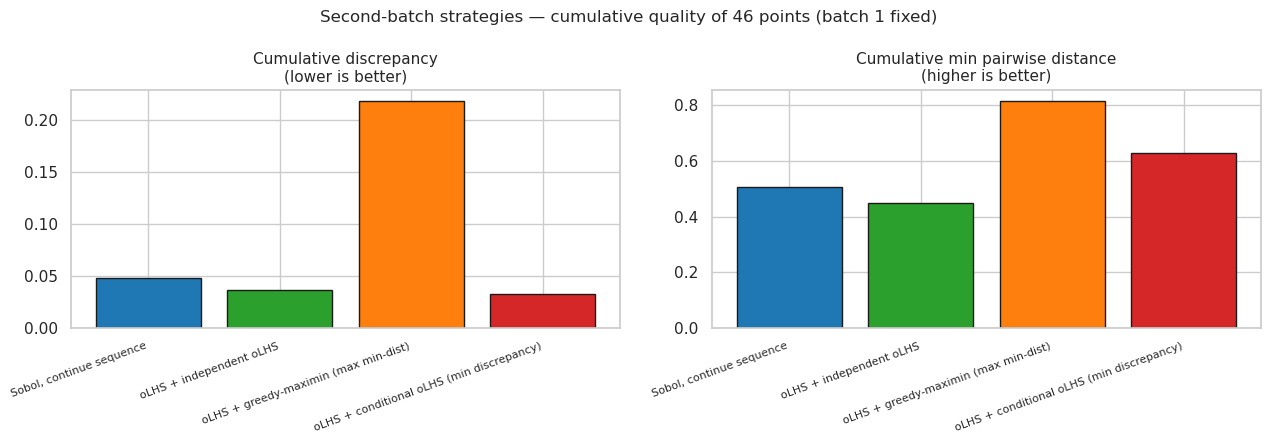

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
order = metrics_ext['second_batch_strategy'].tolist()
colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']
for ax, (col, lbl, better) in zip(axes, [
        ('cum_discrepancy', 'Cumulative discrepancy', 'lower is better'),
        ('cum_min_dist', 'Cumulative min pairwise distance', 'higher is better')]):
    ax.bar(range(len(order)), metrics_ext[col], color=colors, edgecolor='k')
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, rotation=20, ha='right', fontsize=8)
    ax.set_title(f'{lbl}\n({better})', fontsize=11)
fig.suptitle(f'Second-batch strategies — cumulative quality of {2*N_CONDITIONS} points '
             f'(batch 1 fixed)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'hfo2_second_batch_comparison.png'), dpi=200, bbox_inches='tight')
plt.show()

**Reading this:** with batch 1 fixed (as it always is once fabricated):

* **conditional oLHS (min discrepancy)** is the best all-round choice — it explicitly minimizes
  *cumulative* discrepancy, so it beats independent oLHS on coverage **and** keeps a healthy
  minimum distance (it naturally avoids piling new points onto batch 1, because doing so would
  raise discrepancy). This is the discrepancy-objective analogue of greedy-maximin.
* **greedy-maximin** still wins raw spacing but edge-loads the points → poor coverage.
* **independent oLHS** is a simple, decent fallback but risks accidental near-duplicates.
* **Sobol continuation** only pays off at much larger cumulative sizes (empirically n ≳ 400 at
  d = 9), so it is not the right tool here.

**Recommendation for a second HfO₂ batch: conditional oLHS** — optimize cumulative discrepancy
with batch 1 fixed. If avoiding any overlap with already-fabricated runs is the top priority,
add an explicit minimum-distance constraint (or fall back to greedy-maximin).

## 2.3 Build it yourself — the conditional discrepancy-optimized LHS

`conditional_olhs_b2` above looks dense, but it is just **five small ideas** glued together. Use
this as a worked tutorial: read the checklist, then in the code cell each task is implemented with
a `# self-check` that prints `PASS`. To actually *learn* it, blank out a function body, re-derive
it, and re-run until its check passes again.

**Your checklist — what you need to build:**

1. **The objective** — a function `cum_disc(b1, b2)` returning the discrepancy of the *stacked*
   `[b1; b2]` set. This is the single number every swap is judged by. (Why stacked? see §2.2 /
   the cross-pair coupling.)
2. **A valid starting point** — generate `b2` as an **optimized LHS** of `n2` points. Starting
   from a good design means the search only has to polish it. *Self-check:* the Latin property —
   exactly one point in each of the `n2` equal bins, in every column.
3. **The move** — `swap_in_column(b2, col, a, b)`: exchange rows `a` and `b` **within one
   column**, in place. *Self-check:* the column's set of values is unchanged (only the pairing
   across columns moves), so `b2` stays a valid LHS.
4. **The accept/revert rule** — greedy hill-climb: apply the swap, recompute `cum_disc`; **keep**
   it if the value dropped, otherwise **undo** it (swap the same two rows back).
5. **The loop** — repeat *(pick random column → pick two random rows → propose → accept/revert)*
   for `n_iter` iterations, tracking the best value.

If you can write those five, you have rebuilt `conditional_olhs_b2` — and, with step 1 changed to
`discrepancy(b2)` alone, the standalone `optimization='random-cd'` too.

In [8]:
# ============================================================
# BUILD-IT-YOURSELF: conditional discrepancy-optimized LHS.
# Each task is implemented + checked. To practice: delete a body,
# re-implement from the checklist, and re-run until PASS prints.
# ============================================================
import numpy as np
from scipy.stats import qmc

# --- Task 1: the objective -- discrepancy of the STACKED design --------------
def cum_disc(b1, b2):
    return qmc.discrepancy(np.vstack([b1, b2]))

_b1 = qmc.LatinHypercube(d=3, seed=0).random(8)
_b2 = qmc.LatinHypercube(d=3, seed=1).random(8)
assert np.isclose(cum_disc(_b1, _b2), qmc.discrepancy(np.vstack([_b1, _b2])))
print("Task 1 PASS - cumulative objective")

# --- Task 2: a valid LHS starting design -------------------------------------
def start_b2(n2, dim, seed):
    return qmc.LatinHypercube(d=dim, optimization="random-cd", seed=seed).random(n2)

_t = start_b2(8, 3, 0)
_bins = np.floor(_t * 8).astype(int)                  # which of the 8 bins each point falls in
assert all(sorted(_bins[:, k].tolist()) == list(range(8)) for k in range(3))
print("Task 2 PASS - Latin start (one point per bin, every column)")

# --- Task 3: the swap move (in place, preserves the column) ------------------
def swap_in_column(b2, col, a, b):
    b2[[a, b], col] = b2[[b, a], col]

_t = start_b2(8, 3, 0).copy()
_before = sorted(_t[:, 1].tolist())
swap_in_column(_t, 1, 0, 5)
assert sorted(_t[:, 1].tolist()) == _before           # same value set -> still Latin
print("Task 3 PASS - swap keeps the column a permutation")

# --- Tasks 4 & 5: accept/revert rule inside the loop -------------------------
def my_conditional_olhs(b1, n2, dim, seed, n_iter=8000):
    rng = np.random.default_rng(seed)
    b2 = start_b2(n2, dim, seed)            # Task 2: good start
    best = cum_disc(b1, b2)                 # Task 1: objective
    for _ in range(n_iter):
        col = rng.integers(dim)
        a, b = rng.choice(n2, 2, replace=False)
        swap_in_column(b2, col, a, b)       # Task 3: propose
        cur = cum_disc(b1, b2)
        if cur < best:                      # Task 4: accept
            best = cur
        else:
            swap_in_column(b2, col, a, b)   # Task 4: revert (swap back)
    return b2, best

# final self-check: the optimizer must not INCREASE cumulative discrepancy
_b1 = qmc.LatinHypercube(d=5, optimization="random-cd", seed=7).random(20)
_start = cum_disc(_b1, start_b2(20, 5, 7))
_b2_opt, _final = my_conditional_olhs(_b1, 20, 5, 7, n_iter=4000)
assert _final <= _start + 1e-12
print(f"Tasks 4-5 PASS - cumulative discrepancy {_start:.5f} -> {_final:.5f}")
print("\nYou have rebuilt conditional_olhs_b2. Change Task 1 to discrepancy(b2) alone")
print("and you have rebuilt scipy's standalone optimization='random-cd'.")

Task 1 PASS - cumulative objective
Task 2 PASS - Latin start (one point per bin, every column)
Task 3 PASS - swap keeps the column a permutation


Tasks 4-5 PASS - cumulative discrepancy 0.01252 -> 0.00655

You have rebuilt conditional_olhs_b2. Change Task 1 to discrepancy(b2) alone
and you have rebuilt scipy's standalone optimization='random-cd'.


In [ ]:
# ============================================================
# YOUR "do it yourself" trial -- restored (your original Tasks 4 & 5 solution).
# Self-contained: defines the one-arg cum_disc(P) + helpers it expects, then restores
# the two-arg cum_disc at the end so the later cells (my_annealed_olhs, §2.5) keep working.
# ============================================================
import pandas as pd

def cum_disc(P): return qmc.discrepancy(P)
def start_b2(n2, dim, seed): return qmc.LatinHypercube(d=dim, optimization="random-cd", seed=seed).random(n2)
def swap_in_column(b2, col, a, b): b2[[a, b], col] = b2[[b, a], col]

# --- Tasks 4 & 5: accept/revert rule inside the loop ---
def my_conditional_olhs(b1, n2, dim, seed, n_iter=8000):
    rng = np.random.default_rng(seed)
    b2 = start_b2(n2, dim, seed)
    all_toagether = np.vstack([b1, b2])
    best_value = cum_disc(all_toagether)
    iter_list = []
    value_list = []
    for i in range(n_iter):
        iter_list.append(i)
        col = rng.integers(dim)
        a, b = rng.choice(n2, 2, replace=True)
        swap_in_column(b2, col, a, b)
        all_toagether_iter = np.vstack([b1, b2])
        best_value_iter = cum_disc(all_toagether_iter)
        if best_value_iter < best_value:
            best_value = best_value_iter
            value_list.append(best_value)
            continue
        else:
            value_list.append(best_value)
            swap_in_column(b2, col, a, b)
    iter_vs_value_series = pd.Series(value_list, iter_list)
    return b2, best_value, iter_vs_value_series

# final self-check: the optimizer must not INCREASE cumulative discrepancy
_b1 = qmc.LatinHypercube(d=5, optimization="random-cd", seed=7).random(20)
all_toagether_start = np.vstack([_b1, start_b2(20, 5, 7)])
_start = cum_disc(all_toagether_start)
_b2_opt, _final, iter_vs_value_series = my_conditional_olhs(_b1, 20, 5, 7, n_iter=40000)
plt.plot(iter_vs_value_series)
assert _final <= _start + 1e-12
print(f"Tasks 4-5 PASS - cumulative discrepancy {_start:.5f} -> {_final:.5f}")
print("\nYou have rebuilt conditional_olhs_b2. Change Task 1 to discrepancy(b2) alone")
print("and you have rebuilt scipy's standalone optimization='random-cd'.")

# restore the two-argument cum_disc so the later cells keep working
def cum_disc(b1, b2): return qmc.discrepancy(np.vstack([b1, b2]))

## 2.4 Task 6 (optional) — simulated annealing: escaping the greedy plateau

Greedy hill-climbing only ever walks downhill, so it gets trapped in the first local minimum it
reaches — the convergence curve flattens and stays flat. **Simulated annealing (SA)** fixes this
with *one* change to the accept rule: it sometimes accepts a *worse* swap, with probability that
**shrinks as the search cools**, letting the search climb out of a basin early on and then settle
as the temperature drops.

**The only differences from the greedy loop (Tasks 4–5):**

1. Track the **current** score `cur` (which may go up) separately from the **best-ever** score, and
   keep a *copy* of the best design — SA can wander away from it, so you must remember it.
2. **Accept rule:** a downhill swap (`Δ < 0`) is always accepted; an uphill swap (`Δ > 0`) is
   accepted with probability `exp(−Δ / T)`. High `T` → accept almost anything (explore);
   `T → 0` → reject all uphill moves (becomes greedy / exploit).
3. **Cooling schedule:** start at a temperature `T0` scaled to a typical uphill move, then multiply
   `T` by `alpha < 1` each iteration so it decays to ~0 by the end.

Everything else — the LHS start, the column-swap move, the revert-on-reject — is identical.

greedy   final discrepancy: 0.00651
annealed final discrepancy: 0.00620   (+4.8% vs greedy)


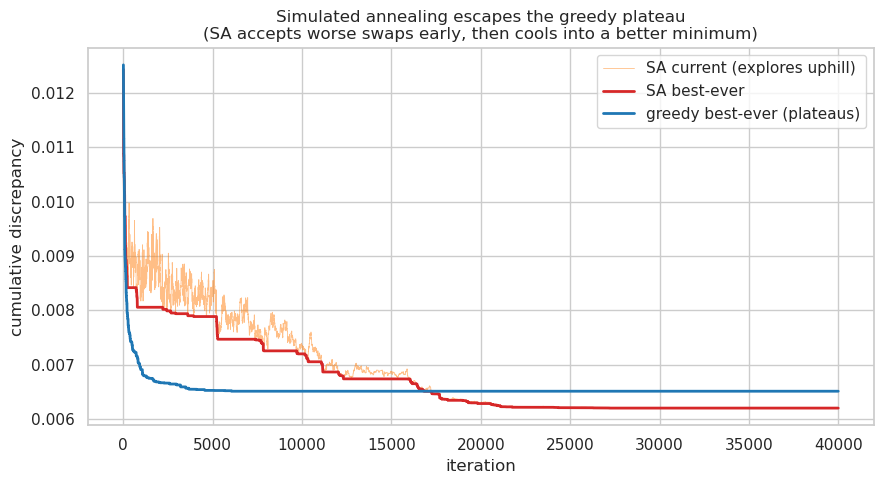

In [9]:
def my_annealed_olhs(b1, n2, dim, seed, n_iter=8000, T_end_frac=1e-3):
    """Conditional discrepancy-minimizing LHS via simulated annealing.
    Same move as greedy; the ONLY change is the probabilistic accept rule + cooling."""
    rng = np.random.default_rng(seed)
    b2 = start_b2(n2, dim, seed)            # Task 2: LHS start
    cur = cum_disc(b1, b2)                  # CURRENT score (allowed to rise)
    best, best_b2 = cur, b2.copy()          # BEST-ever score + its design (SA may wander off it)

    # auto-scale starting temperature to a typical uphill move (so ~half are accepted at first)
    ups = []
    for _ in range(200):
        col = rng.integers(dim); a, b = rng.choice(n2, 2, replace=False)
        swap_in_column(b2, col, a, b); d = cum_disc(b1, b2) - cur
        swap_in_column(b2, col, a, b)       # revert the probe
        if d > 0: ups.append(d)
    T0 = float(np.mean(ups)) if ups else 1e-3
    alpha = T_end_frac ** (1.0 / n_iter)    # geometric cooling -> T0*T_end_frac by the end
    T = T0

    best_curve, cur_curve = [], []
    for _ in range(n_iter):
        col = rng.integers(dim); a, b = rng.choice(n2, 2, replace=False)
        swap_in_column(b2, col, a, b)       # propose
        cand = cum_disc(b1, b2)
        delta = cand - cur
        if delta < 0 or rng.random() < np.exp(-delta / max(T, 1e-12)):
            cur = cand                      # ACCEPT (downhill always; uphill w.p. exp(-d/T))
            if cur < best:
                best, best_b2 = cur, b2.copy()
        else:
            swap_in_column(b2, col, a, b)   # REJECT -> revert
        T *= alpha                          # cool
        best_curve.append(best); cur_curve.append(cur)
    return best_b2, best, np.array(best_curve), np.array(cur_curve)

# --- Greedy (Tasks 4-5) vs simulated annealing on the same problem ---
def greedy_curve(b1, n2, dim, seed, n_iter):
    rng = np.random.default_rng(seed); b2 = start_b2(n2, dim, seed); best = cum_disc(b1, b2); c = []
    for _ in range(n_iter):
        col = rng.integers(dim); a, b = rng.choice(n2, 2, replace=False)
        swap_in_column(b2, col, a, b)
        if cum_disc(b1, b2) < best: best = cum_disc(b1, b2)
        else: swap_in_column(b2, col, a, b)
        c.append(best)
    return best, np.array(c)

N_IT = 40000
_b1 = qmc.LatinHypercube(d=5, optimization="random-cd", seed=7).random(20)
g_best, g_curve = greedy_curve(_b1, 20, 5, 7, N_IT)
_, a_best, a_best_curve, a_cur_curve = my_annealed_olhs(_b1, 20, 5, 7, n_iter=N_IT)
print(f"greedy   final discrepancy: {g_best:.5f}")
print(f"annealed final discrepancy: {a_best:.5f}   ({100*(g_best-a_best)/g_best:+.1f}% vs greedy)")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(a_cur_curve,  color="#ff7f0e", lw=0.6, alpha=0.5, label="SA current (explores uphill)")
ax.plot(a_best_curve, color="#d62728", lw=2,   label="SA best-ever")
ax.plot(g_curve,      color="#1f77b4", lw=2,   label="greedy best-ever (plateaus)")
ax.set_xlabel("iteration"); ax.set_ylabel("cumulative discrepancy")
ax.set_title("Simulated annealing escapes the greedy plateau\n"
             "(SA accepts worse swaps early, then cools into a better minimum)")
ax.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "annealing_vs_greedy.png"), dpi=200, bbox_inches="tight")
plt.show()

**What the plot shows.** The greedy curve (blue) drops fast then **freezes** at its first local
minimum. The SA *current* score (faint orange) is allowed to bounce *upward* early on — that's the
search escaping basins — while the SA *best-ever* (red) ratchets down past where greedy got stuck.
As `T` cools, the orange bouncing dies out and SA converges. Net result here: a lower-discrepancy
design than greedy can reach, at the cost of more iterations and two extra knobs (`T0`, `alpha`).
This probabilistic-accept-plus-cooling is essentially the refinement scipy's
`optimization='random-cd'` uses internally on top of the plain greedy swap search you built in
Tasks 4–5.

## 2.5 Five sequential batches — Sobol vs LHS+SA over the long run

§2.2–2.4 looked at one or two batches. Here we extend to **5 sequential batches of 23 conditions**
(up to 115 cumulative points) and track quality *as each batch lands*, to see whether Sobol's
asymptotic advantage ever overtakes the conditional optimizer in a realistic multi-batch campaign:

* **Sobol (continue)** — keep drawing 23 from one continued Sobol sequence each batch.
* **Pure LHS** — a fresh *plain* Latin Hypercube each batch (no discrepancy optimization, no
  coordination with prior batches), pooled. The naive multi-batch baseline.
* **LHS + SA (conditional)** — batch 1 = optimized LHS; every later batch = simulated-annealing
  fill that freezes all previously-fabricated runs (`my_annealed_olhs` with the cumulative set as
  its fixed block). Note `my_annealed_olhs(empty, ...)` reduces to a plain optimized LHS, so the
  *same* function generates batch 1 and every extension.

Tracked at each cumulative size: **discrepancy** (coverage), **max |off-diagonal correlation|**
(factor independence), and **minimum pairwise distance** (no near-duplicate runs), averaged over
4 seeds.

**Fair-comparison note.** Every method here is evaluated **as fabricated** — each design is snapped
to the slide's resolution grid (integer W, 5 °C, 0.1 nm, 0.1 min) *including the 2-level Ox Press*
constraint — before its metrics are computed. That way all three live under the identical
constraint and are truly comparable.

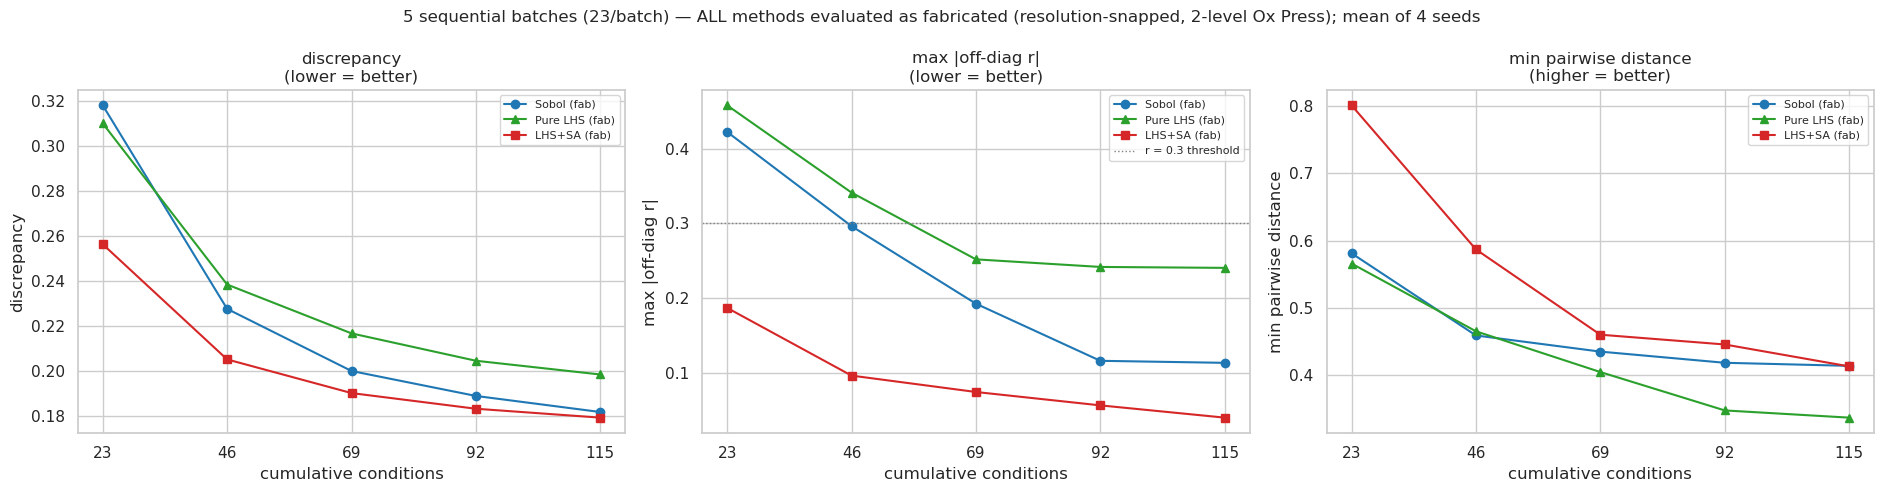

,batch,cum_conditions,Sobol (fab)_disc,Sobol (fab)_maxr,Sobol (fab)_mind,Pure LHS (fab)_disc,Pure LHS (fab)_maxr,Pure LHS (fab)_mind,LHS+SA (fab)_disc,LHS+SA (fab)_maxr,LHS+SA (fab)_mind
0,1,23,0.31805,0.422,0.5811,0.31003,0.458,0.5659,0.25626,0.187,0.8010
1,2,46,0.22753,0.296,0.4591,0.23835,0.341,0.4652,0.20505,0.096,0.5869
2,3,69,0.19990,0.192,0.4351,0.21663,0.252,0.4047,0.19008,0.074,0.4602
3,4,92,0.18880,0.116,0.4185,0.20445,0.242,0.3477,0.18311,0.056,0.4457
4,5,115,0.18166,0.113,0.4139,0.19834,0.240,0.3370,0.17916,0.040,0.4131


In [58]:
def _maxoff_pts(P):
    C = np.corrcoef(P.T); np.fill_diagonal(C, 0.0); return np.abs(C).max()

def _round_norm(P_unit):
    """Map a unit-cube design to the physical resolution grid, then back to [0,1] for metrics
    -- i.e. evaluate the design AS FABRICATED (steps + 2-level Ox Press)."""
    phys = np.array([[map_parameter(P_unit[r, i], HFO2_CONFIG[FACTORS[i]]) for i in range(d)]
                     for r in range(len(P_unit))])
    return normalise_for_metrics(pd.DataFrame(phys, columns=FACTORS), HFO2_CONFIG)

NB_BATCHES, SEEDS5 = 5, 4
ns5 = [N_CONDITIONS * (k + 1) for k in range(NB_BATCHES)]
# TRUE comparison: every method is evaluated AS FABRICATED (snapped to the resolution grid,
# incl. the 2-level Ox Press), so all three sit under the identical constraint.
methods = ("Sobol (fab)", "Pure LHS (fab)", "LHS+SA (fab)")
M = {m: {q: np.zeros((SEEDS5, NB_BATCHES)) for q in ("disc", "maxr", "mind")} for m in methods}

def _record(store, si, k, P):
    store["disc"][si, k] = qmc.discrepancy(P)
    store["maxr"][si, k] = _maxoff_pts(P)
    store["mind"][si, k] = pdist(P).min()

for si, seed in enumerate(range(SEEDS5)):
    eng = qmc.Sobol(d=d, scramble=True, seed=seed)
    sob = np.empty((0, d)); plhs = np.empty((0, d)); sa = np.empty((0, d))
    for k in range(NB_BATCHES):
        sob  = np.vstack([sob,  eng.random(N_CONDITIONS)])                       # continue sequence
        plhs = np.vstack([plhs, qmc.LatinHypercube(d=d, seed=seed * 100 + k)     # fresh plain LHS
                                   .random(N_CONDITIONS)])
        sa   = np.vstack([sa,   my_annealed_olhs(sa, N_CONDITIONS, d,            # freeze all prior
                                                 seed * 10 + k, n_iter=5000)[0]])
        _record(M["Sobol (fab)"],    si, k, _round_norm(sob))    # all three snapped to the grid
        _record(M["Pure LHS (fab)"], si, k, _round_norm(plhs))   #   (incl. 2-level Ox Press)
        _record(M["LHS+SA (fab)"],   si, k, _round_norm(sa))

batch5 = pd.DataFrame({"batch": range(1, NB_BATCHES + 1), "cum_conditions": ns5})
for m in M:
    batch5[f"{m}_disc"] = M[m]["disc"].mean(0).round(5)
    batch5[f"{m}_maxr"] = M[m]["maxr"].mean(0).round(3)
    batch5[f"{m}_mind"] = M[m]["mind"].mean(0).round(4)
batch5.to_excel(os.path.join(OUT_DIR, "hfo2_5batch_metrics.xlsx"), index=False)

styles = {"Sobol (fab)": ("o-", "#1f77b4"), "Pure LHS (fab)": ("^-", "#2ca02c"),
          "LHS+SA (fab)": ("s-", "#d62728")}
panels = [("disc", "discrepancy", "lower = better", True),
          ("maxr", "max |off-diag r|", "lower = better", False),
          ("mind", "min pairwise distance", "higher = better", False)]
fig, ax = plt.subplots(1, 3, figsize=(19, 5))
for a, (q, ylab, better, logy) in zip(ax, panels):
    for m, (ls, c) in styles.items():
        a.plot(ns5, M[m][q].mean(0), ls, color=c, label=m)
    if q == "maxr":
        a.axhline(0.3, ls=":", color="gray", lw=1, label="r = 0.3 threshold")
    # if logy:
    #     a.set_yscale("log")
    a.set_xlabel("cumulative conditions"); a.set_ylabel(ylab)
    a.set_title(f"{ylab}\n({better})"); a.legend(fontsize=8); a.set_xticks(ns5)
fig.suptitle("5 sequential batches (23/batch) — ALL methods evaluated as fabricated "
             "(resolution-snapped, 2-level Ox Press); mean of 4 seeds", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "hfo2_5batch_sobol_vs_sa.png"), dpi=180, bbox_inches="tight")
plt.show()
batch5

**Result over 5 batches (all evaluated as fabricated).** Under the identical fabrication
constraint, **LHS+SA still wins on every metric**: lowest **discrepancy** (Sobol second, pure LHS
worst), lowest **correlation** (under the 0.3 threshold throughout, while Sobol/pure LHS sit
higher), and highest **min pairwise distance**. So applying the Ox Press constraint to *all*
methods — the truly fair comparison — does **not** change the ranking.

**Why every line's discrepancy is elevated.** All three sit on the same raised discrepancy floor
because the **2-level Ox Press** factor (0.01/0.02 atm) forces one of the nine axes onto just two
values — a hard process constraint shared by every method. A decomposition confirms Ox Press is the
whole story: snapping *only the times* changes discrepancy by **nothing** (they keep thousands of
levels at 0.1-min resolution), snapping everything *except* Ox Press adds very little, and Ox Press
alone accounts for essentially the entire increase. (That zero time-cost is also why we set the
time step to a clean 0.1 min instead of 1 s.)

## 3. Per-factor distributions

Each swept factor should fill its full allowed range (no clumping). Discrete factors
(O₂ flow's *0 sccm* option, oxidation pressure) are shown as level counts.

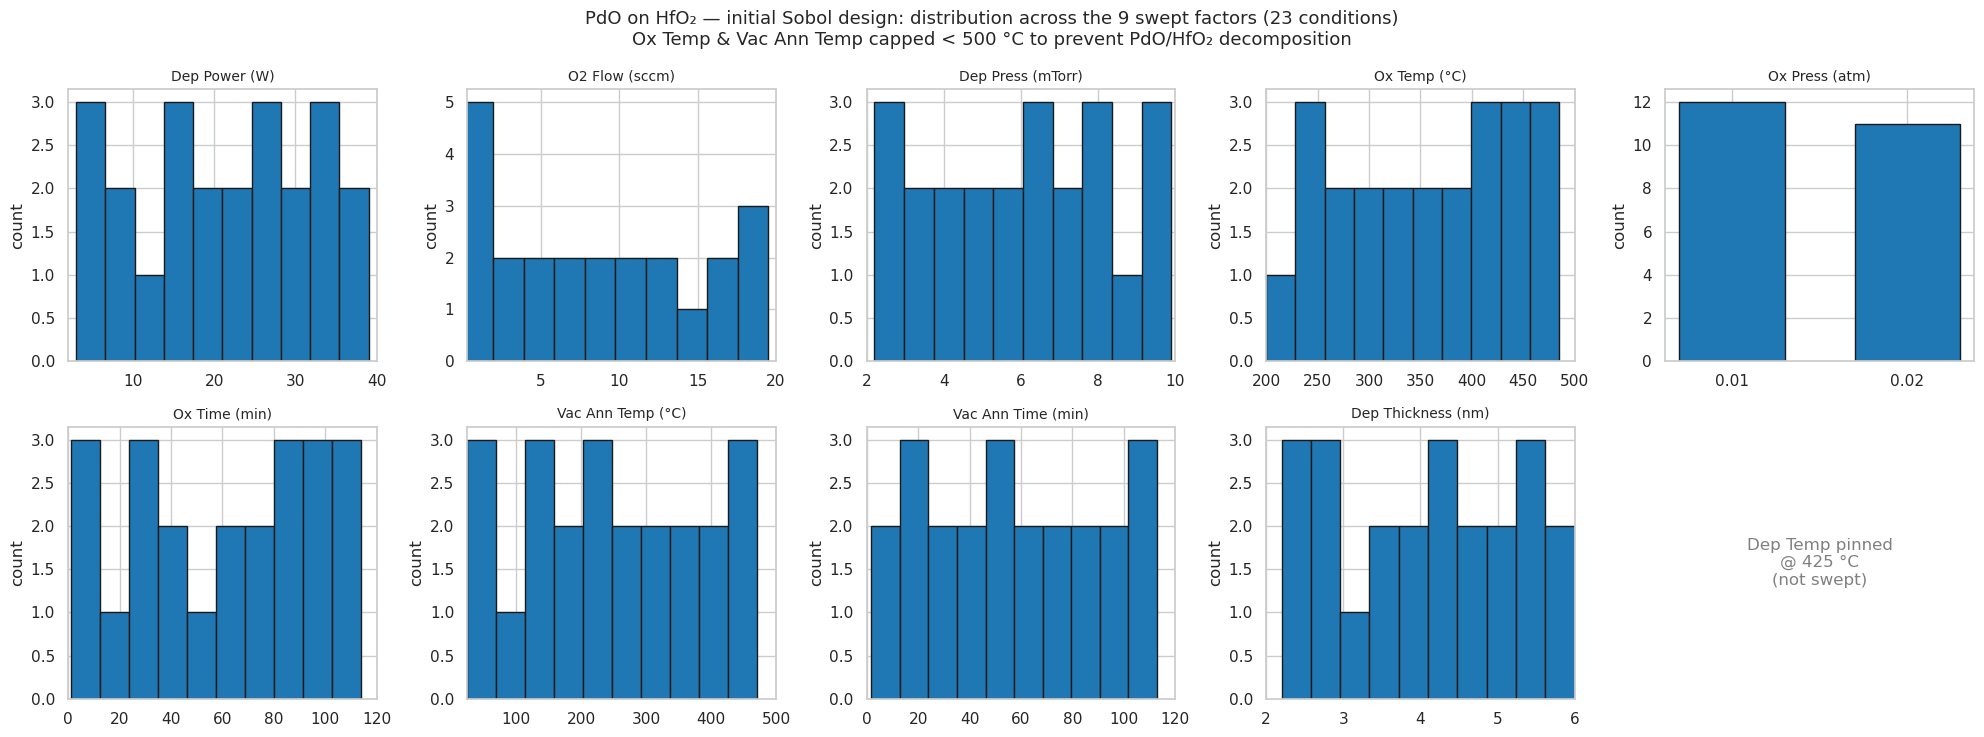

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7.5))
for ax, f in zip(axes.flat, FACTORS):
    vals = df_plan[f]
    settings = HFO2_CONFIG[f]
    if isinstance(settings, list):                       # discrete levels -> bar
        levels = sorted(settings)
        counts = [int((vals == lv).sum()) for lv in levels]
        ax.bar([str(lv) for lv in levels], counts, color='#1f77b4', edgecolor='k', width=0.6)
    else:
        ax.hist(vals, bins=10, color='#1f77b4', edgecolor='k')
        ax.set_xlim(settings['min'], settings['max'])
    ax.set_title(f, fontsize=10); ax.set_ylabel('count')
# blank the unused 10th panel (we have 9 swept factors)
axes.flat[9].axis('off')
axes.flat[9].text(0.5, 0.5, f'Dep Temp pinned\n@ {DEP_TEMP_FIXED:g} °C\n(not swept)',
                  ha='center', va='center', fontsize=12, color='gray')
fig.suptitle(f'PdO on HfO₂ — initial Sobol design: distribution across the 9 swept factors '
             f'({N_CONDITIONS} conditions)\nOx Temp & Vac Ann Temp capped < 500 °C to prevent PdO/HfO₂ decomposition',
             fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'hfo2_all_factor_distributions.png'), dpi=200, bbox_inches='tight')
plt.show()

### 3.1 Pair plot — 2-D coverage of the swept factors

The per-factor histograms above confirm each factor fills its *1-D* range. The pair plot below
checks the *2-D* projections: every factor-vs-factor panel should look **evenly scattered with no
diagonal banding** — points spread across the plane and no spurious correlation between factors
(a space-filling design keeps the inputs roughly independent so their effects can be told apart).
Diagonal panels repeat the 1-D marginals; only the lower triangle is shown to cut clutter. We plot
the 23 unique conditions (replicates would just overplot).

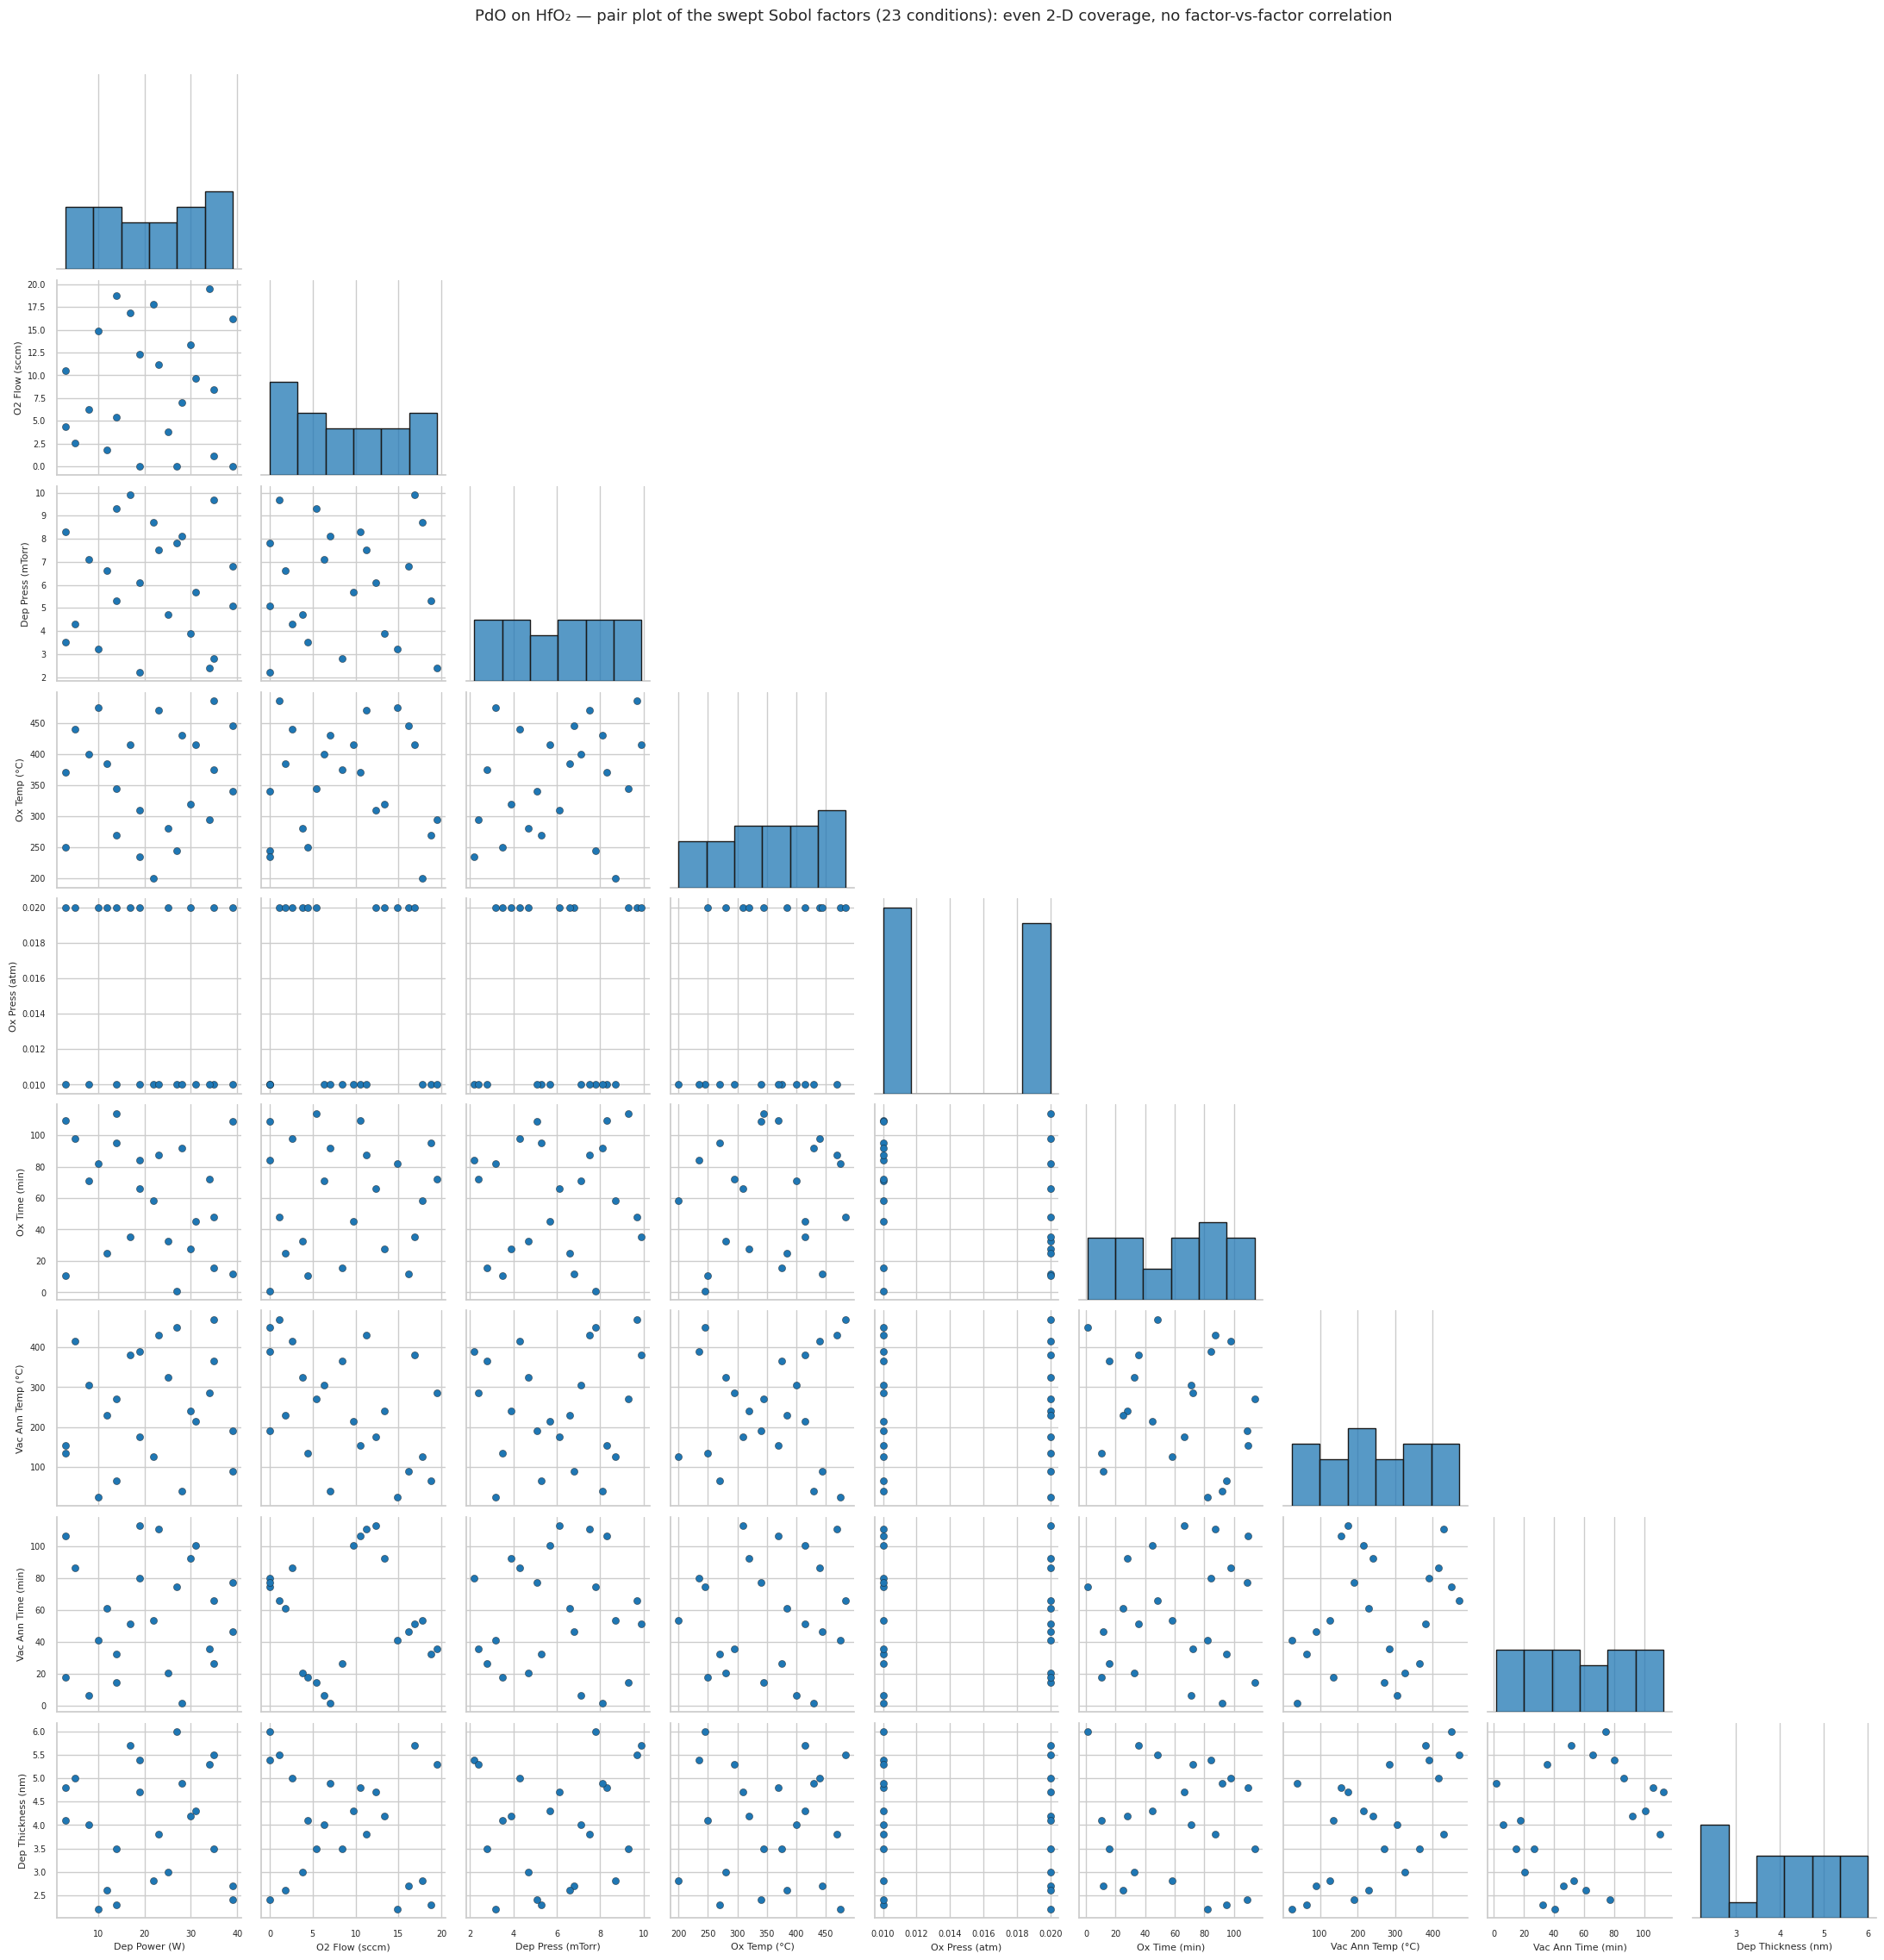

In [12]:
# Pair plot of the 9 swept factors (Dep Temp is pinned -> constant, so excluded).
g = sns.pairplot(df_plan[FACTORS], corner=True, diag_kind="hist",
                 plot_kws=dict(s=34, color="#1f77b4", edgecolor="k", linewidth=0.3),
                 diag_kws=dict(color="#1f77b4", edgecolor="k"))
g.fig.suptitle("PdO on HfO₂ — pair plot of the swept Sobol factors "
               f"({N_CONDITIONS} conditions): even 2-D coverage, no factor-vs-factor correlation",
               y=1.02, fontsize=13)
for ax in g.axes.flatten():
    if ax is not None:
        ax.tick_params(labelsize=7)
        ax.xaxis.label.set_size(8); ax.yaxis.label.set_size(8)
g.savefig(os.path.join(OUT_DIR, "hfo2_pairplot_factors.png"), dpi=180, bbox_inches="tight")
plt.show()

### 3.3 Two-batch correlation: Sobol vs simulated-annealing

§3.1–3.2 looked at the **single-batch Sobol** design that we export. Here we compare the
**cumulative 46-point** correlation of two *two-batch* strategies from §2.2 / §2.4, since
correlation (like discrepancy) is a property of the full pooled design:

* **Sobol 2-batch** — batch 1 + batch 2 by continuing the same Sobol sequence.
* **SA 2-batch** — batch 1 (optimized LHS) + batch 2 from the **simulated-annealing** conditional
  optimizer (`my_annealed_olhs`), which minimizes cumulative discrepancy.

Both are evaluated in the unit cube (column *i* ↔ swept factor *i*; affine mapping to physical
units doesn't change Pearson *r*). Heatmaps are one representative seed; the printed max/mean |*r*|
are averaged over 8 seeds for robustness.

cumulative 46-point correlation (mean over 8 seeds):
  Sobol 2-batch : max|r|=0.338   mean|r|=0.074
  SA    2-batch : max|r|=0.070   mean|r|=0.022


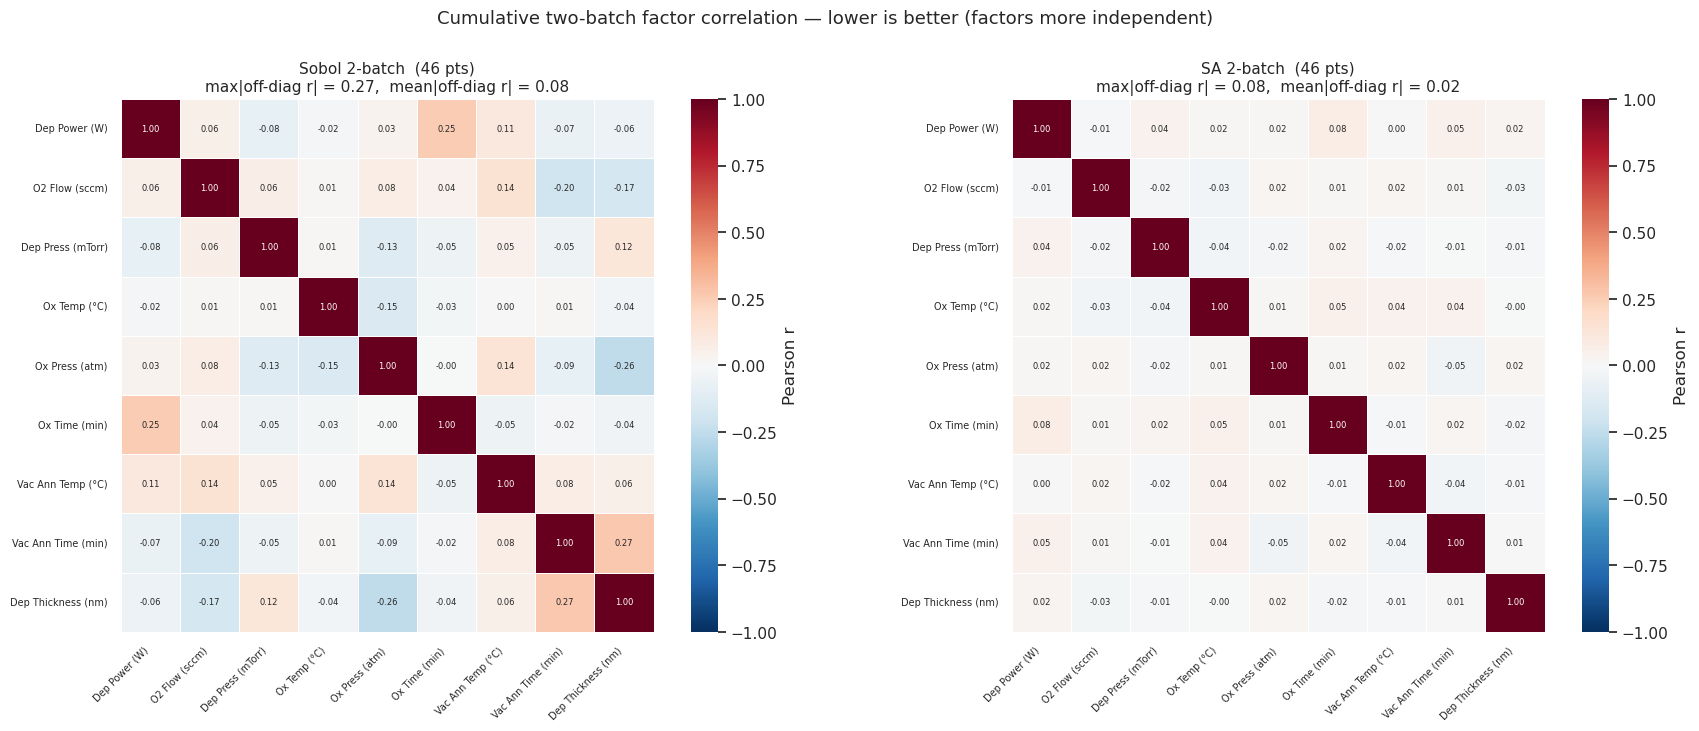

In [14]:
def _off(C):                                   # off-diagonal |correlation| stats
    M = C.values.copy(); np.fill_diagonal(M, 0.0)
    return np.abs(M).max(), np.abs(C.values[~np.eye(len(C), dtype=bool)]).mean()

def sobol_2batch(seed):
    eng = qmc.Sobol(d=d, scramble=True, seed=seed)
    return np.vstack([eng.random(N_CONDITIONS), eng.random(N_CONDITIONS)])

def sa_2batch(seed):
    b1 = start_b2(N_CONDITIONS, d, seed)
    b2 = my_annealed_olhs(b1, N_CONDITIONS, d, seed, n_iter=8000)[0]
    return np.vstack([b1, b2])

# seed-averaged headline numbers
s_max, s_mean, a_max, a_mean = [], [], [], []
for seed in range(8):
    cs = _off(pd.DataFrame(sobol_2batch(seed), columns=FACTORS).corr())
    ca = _off(pd.DataFrame(sa_2batch(seed),    columns=FACTORS).corr())
    s_max.append(cs[0]); s_mean.append(cs[1]); a_max.append(ca[0]); a_mean.append(ca[1])
print("cumulative 46-point correlation (mean over 8 seeds):")
print(f"  Sobol 2-batch : max|r|={np.mean(s_max):.3f}   mean|r|={np.mean(s_mean):.3f}")
print(f"  SA    2-batch : max|r|={np.mean(a_max):.3f}   mean|r|={np.mean(a_mean):.3f}")

# heatmaps for one representative seed
C_sob = pd.DataFrame(sobol_2batch(GLOBAL_SEED), columns=FACTORS).corr()
C_sa  = pd.DataFrame(sa_2batch(GLOBAL_SEED),    columns=FACTORS).corr()
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, C, name in [(axes[0], C_sob, "Sobol 2-batch"), (axes[1], C_sa, "SA 2-batch")]:
    mx, mn = _off(C)
    sns.heatmap(C, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
                square=True, linewidths=0.5, annot_kws={"size": 6},
                cbar_kws={"label": "Pearson r"}, ax=ax)
    ax.set_title(f"{name}  (46 pts)\nmax|off-diag r| = {mx:.2f},  mean|off-diag r| = {mn:.2f}",
                 fontsize=11)
    ax.tick_params(labelsize=7); ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
fig.suptitle("Cumulative two-batch factor correlation — lower is better (factors more independent)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "hfo2_2batch_correlation_compare.png"), dpi=180, bbox_inches="tight")
plt.show()

**Result.** The simulated-annealing two-batch design is **markedly less correlated** than
continuing the Sobol sequence (≈5× lower max |*r*| across seeds). This is a *side benefit* of
minimizing cumulative discrepancy: spreading points uniformly in the joint space also drives the
pairwise correlations toward zero. So the conditional SA optimizer wins on **both** the coverage
metric it explicitly targets *and* factor independence — another reason to prefer it over Sobol
continuation for a second HfO₂ batch.

### 3.4 The Ox Press constraint — pair plot & correlation of the SA fabrication design

§3.1–3.3 used the Sobol design. Here we look at the **SA design we actually export**
(`PdO_HfO2_SimulatedAnnealing_design.xlsx`, 23 conditions) and make the **2-level Ox Press
constraint** explicit. Ox Press takes only `{0.01, 0.02}` atm, so in the pair plot we **color
points by Ox Press level** — every other factor should be evenly covered *within each pressure
group* (the constraint splits the runs into two pressure cohorts, not into two separated clusters
in the other factors). The correlation matrix then quantifies how independent the factors remain
*with* the binary Ox Press included (a binary column can only ever show point-biserial
correlation, so a small non-zero row for Ox Press is expected).

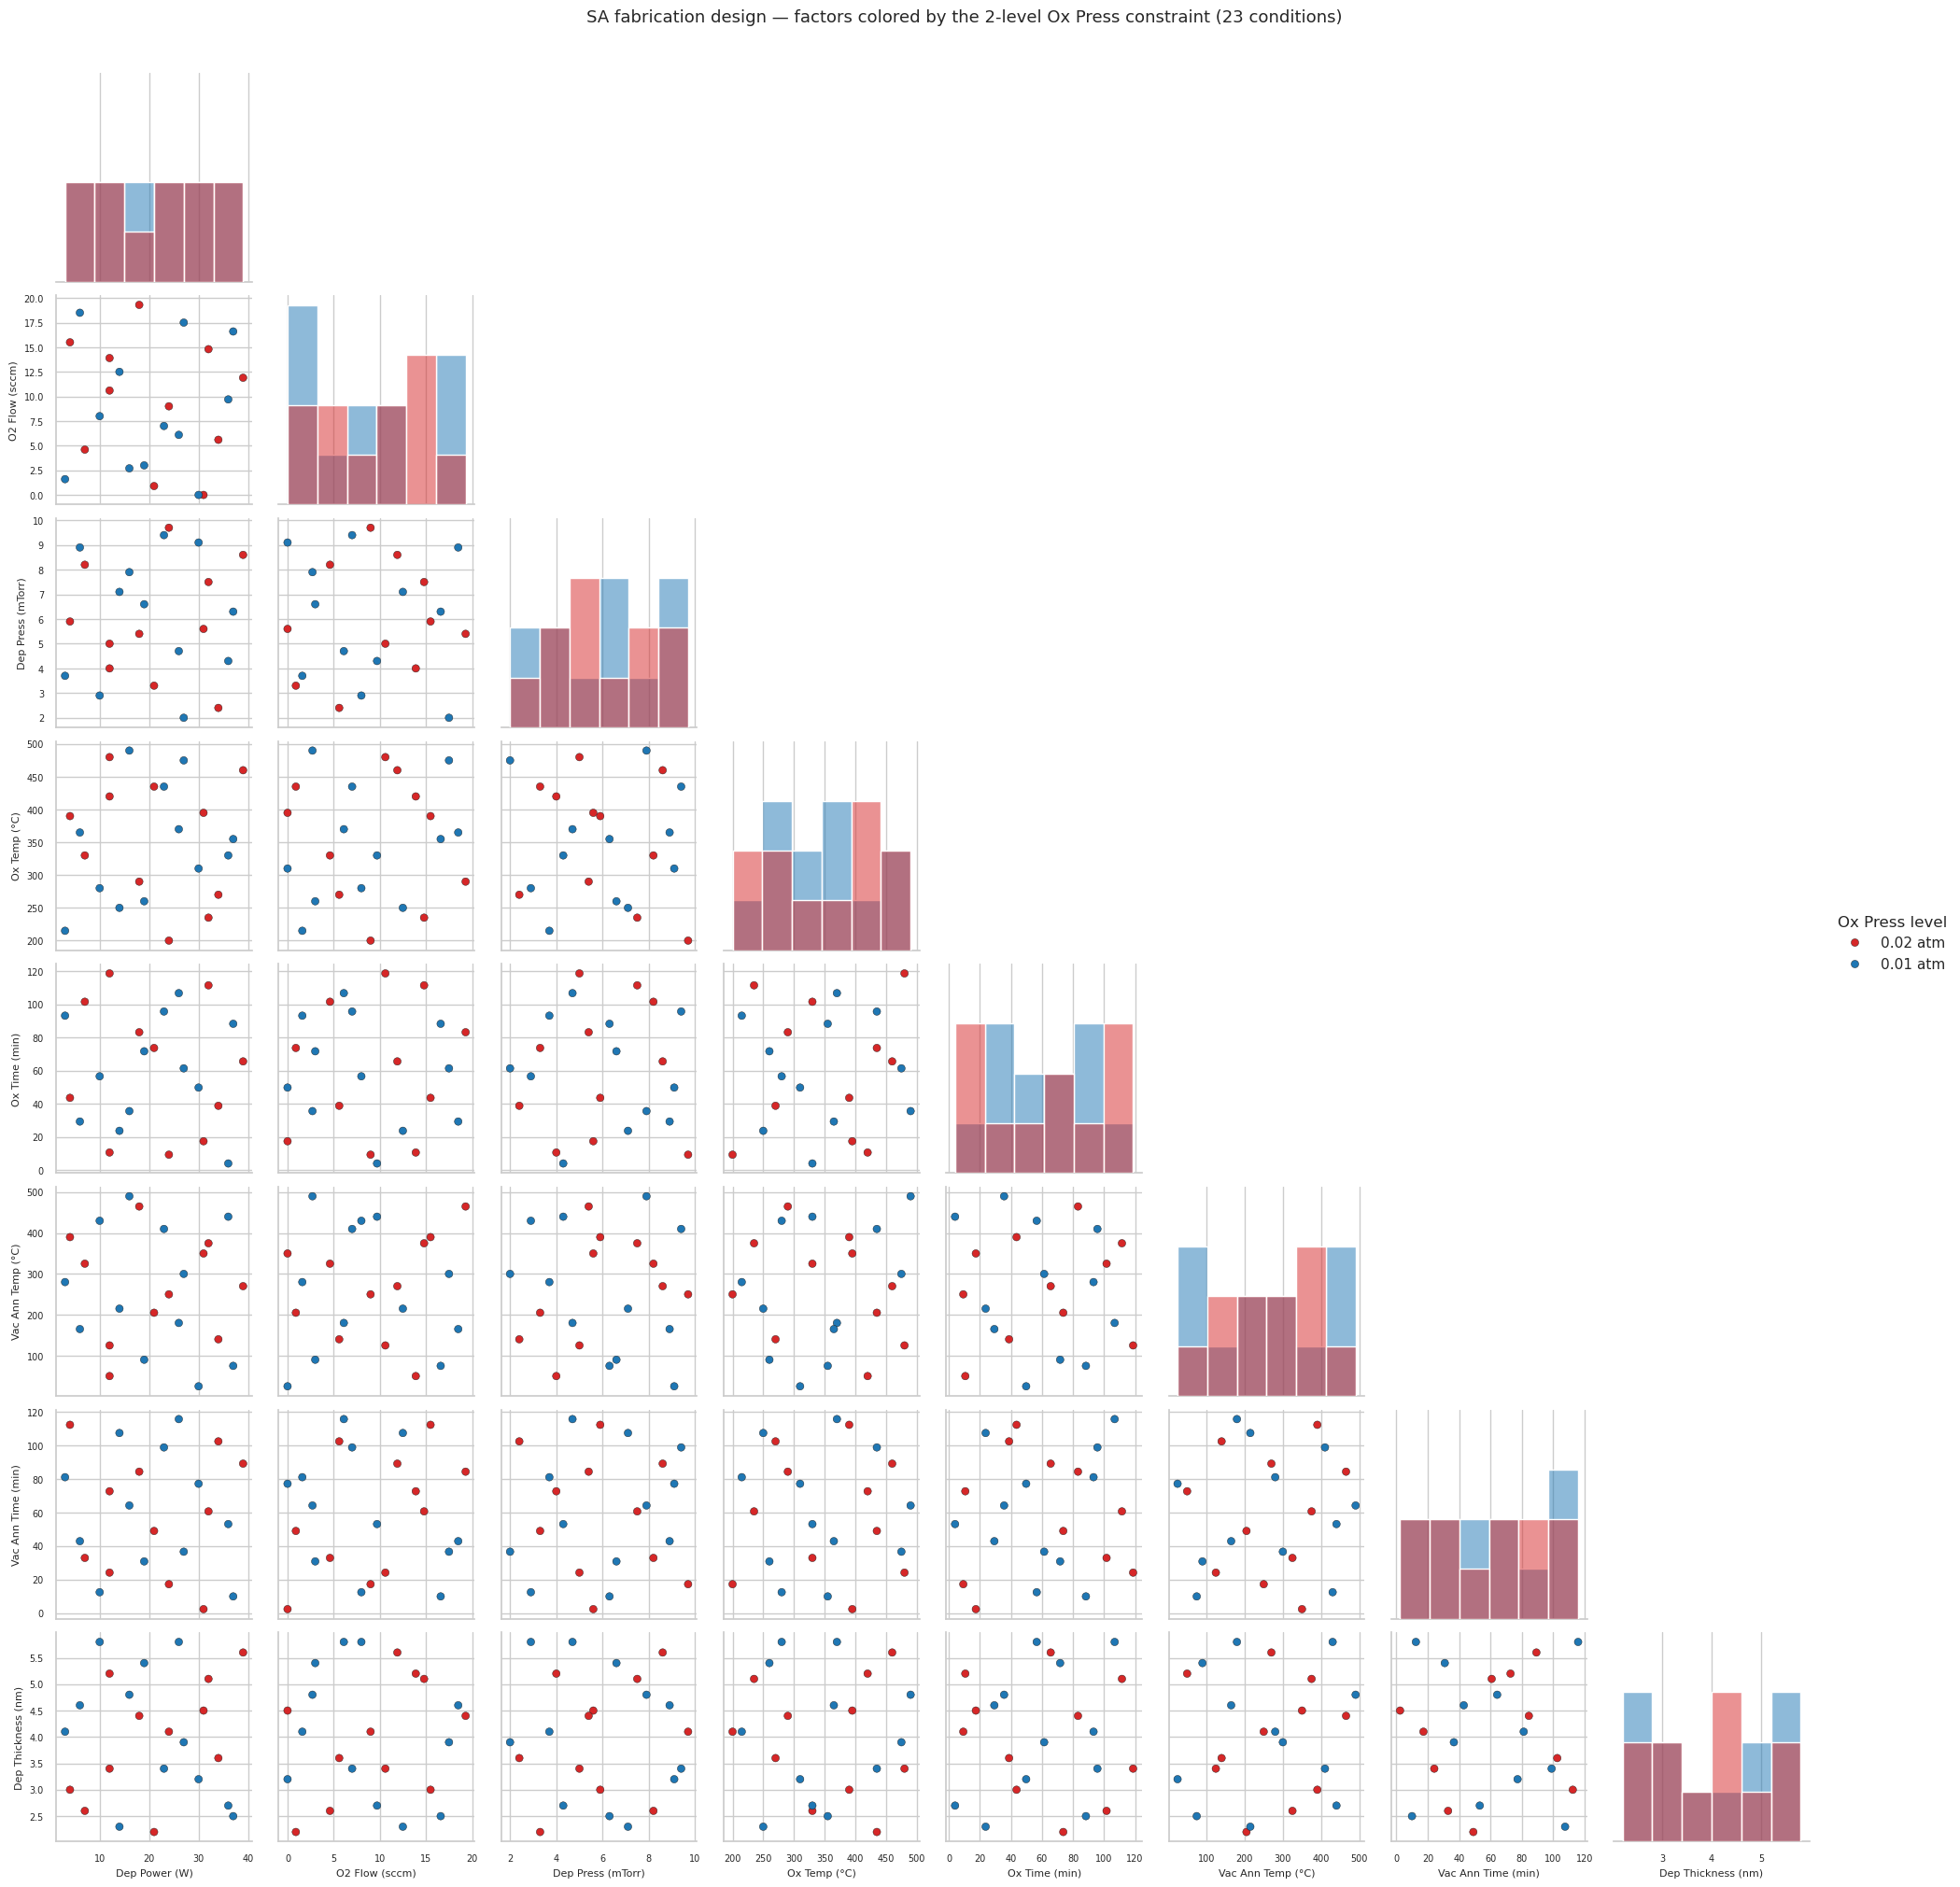

Ox Press split: {'0.01 atm': 12, '0.02 atm': 11}


In [15]:
# Rebuild the exported SA design (23 conditions) in physical units
U_sa = my_annealed_olhs(np.empty((0, d)), N_CONDITIONS, d, GLOBAL_SEED, n_iter=12000)[0]
phys = np.array([[map_parameter(U_sa[r, i], HFO2_CONFIG[FACTORS[i]]) for i in range(d)]
                 for r in range(N_CONDITIONS)])
df_sa = pd.DataFrame(phys, columns=FACTORS)
df_sa["Ox Press (atm)"] = df_sa["Ox Press (atm)"].round(2)
df_sa["Ox Press level"] = df_sa["Ox Press (atm)"].map({0.01: "0.01 atm", 0.02: "0.02 atm"})

other = [f for f in FACTORS if f != "Ox Press (atm)"]   # 8 factors, colored by the 2 pressure levels
g = sns.pairplot(df_sa, vars=other, hue="Ox Press level", corner=True, diag_kind="hist",
                 palette={"0.01 atm": "#1f77b4", "0.02 atm": "#d62728"},
                 plot_kws=dict(s=34, edgecolor="k", linewidth=0.3))
g.fig.suptitle("SA fabrication design — factors colored by the 2-level Ox Press constraint "
               f"({N_CONDITIONS} conditions)", y=1.02, fontsize=13)
for ax in g.axes.flatten():
    if ax is not None:
        ax.tick_params(labelsize=7); ax.xaxis.label.set_size(8); ax.yaxis.label.set_size(8)
g.savefig(os.path.join(OUT_DIR, "hfo2_sa_pairplot_oxpress.png"), dpi=170, bbox_inches="tight")
plt.show()
print("Ox Press split:", df_sa["Ox Press level"].value_counts().to_dict())

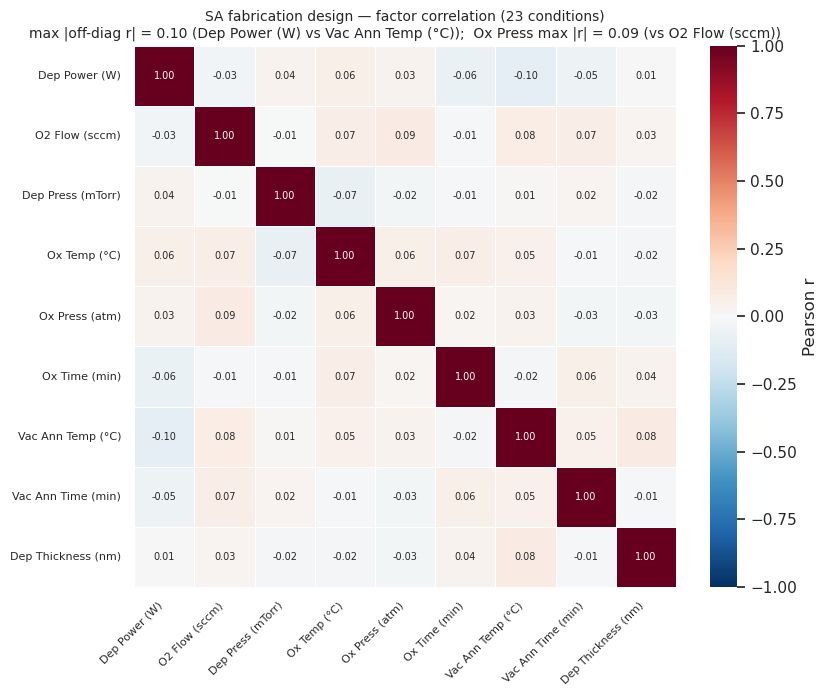

overall max |off-diag r| = 0.098 (Dep Power (W) vs Vac Ann Temp (°C))
Ox Press largest |r| with any factor = 0.086 (vs O2 Flow (sccm))


,Dep Power (W),O2 Flow (sccm),Dep Press (mTorr),Ox Temp (°C),Ox Press (atm),Ox Time (min),Vac Ann Temp (°C),Vac Ann Time (min),Dep Thickness (nm)
Dep Power (W),1.00,-0.03,0.04,0.06,0.03,-0.06,-0.10,-0.05,0.01
O2 Flow (sccm),-0.03,1.00,-0.01,0.07,0.09,-0.01,0.08,0.07,0.03
Dep Press (mTorr),0.04,-0.01,1.00,-0.07,-0.02,-0.01,0.01,0.02,-0.02
Ox Temp (°C),0.06,0.07,-0.07,1.00,0.06,0.07,0.05,-0.01,-0.02
Ox Press (atm),0.03,0.09,-0.02,0.06,1.00,0.02,0.03,-0.03,-0.03
Ox Time (min),-0.06,-0.01,-0.01,0.07,0.02,1.00,-0.02,0.06,0.04
Vac Ann Temp (°C),-0.10,0.08,0.01,0.05,0.03,-0.02,1.00,0.05,0.08
Vac Ann Time (min),-0.05,0.07,0.02,-0.01,-0.03,0.06,0.05,1.00,-0.01
Dep Thickness (nm),0.01,0.03,-0.02,-0.02,-0.03,0.04,0.08,-0.01,1.00


In [16]:
# Correlation matrix of the SA fabrication design (binary Ox Press included)
corr_sa = df_sa[FACTORS].corr()
off = corr_sa.where(~np.eye(len(corr_sa), dtype=bool))
mx = off.abs().max().max()
ip, jp = np.unravel_index(np.nanargmax(off.abs().values), off.shape)
# Ox Press-specific: its largest correlation with any other factor
oxp = corr_sa["Ox Press (atm)"].drop("Ox Press (atm)")
oxp_max = oxp.abs().max(); oxp_with = oxp.abs().idxmax()

fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(corr_sa, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, annot_kws={"size": 7}, cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title(f"SA fabrication design — factor correlation ({N_CONDITIONS} conditions)\n"
             f"max |off-diag r| = {mx:.2f} ({FACTORS[ip]} vs {FACTORS[jp]});  "
             f"Ox Press max |r| = {oxp_max:.2f} (vs {oxp_with})", fontsize=10)
plt.xticks(rotation=45, ha="right", fontsize=8); plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "hfo2_sa_correlation_oxpress.png"), dpi=200, bbox_inches="tight")
plt.show()
print(f"overall max |off-diag r| = {mx:.3f} ({FACTORS[ip]} vs {FACTORS[jp]})")
print(f"Ox Press largest |r| with any factor = {oxp_max:.3f} (vs {oxp_with})")
corr_sa.round(2)

**Reading it.** The pair plot shows the two Ox Press cohorts (blue = 0.01 atm, red = 0.02 atm)
interleaved across every other factor — the constraint partitions the *pressure* axis only, while
the remaining eight factors stay well mixed within each cohort (no blue/red separation), which is
exactly what we want: Ox Press is controlled without confounding the other factors. The correlation
matrix confirms it numerically — Ox Press's largest correlation with any other factor stays small,
so even though it is binary it is not aliased with another process knob.

## 4. Temperature plane — the decomposition-safe region

Because PdO on HfO₂ decomposes at ≥ ~510 °C, both temperatures are confined below 500 °C.
The plot below shows the design lives entirely inside the safe box, unlike the PdO-on-Al₂O₃
design whose oxidation temperatures ran up to 800 °C.

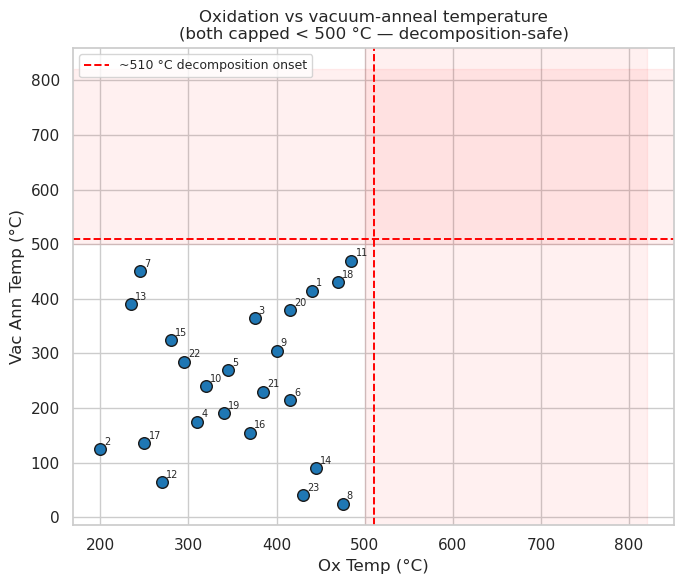

In [17]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df_plan['Ox Temp (°C)'], df_plan['Vac Ann Temp (°C)'],
           c='#1f77b4', s=70, edgecolor='k', zorder=3)
for _, r in df_plan.iterrows():
    ax.annotate(int(r.name) + 1, (r['Ox Temp (°C)'], r['Vac Ann Temp (°C)']),
                fontsize=7, xytext=(3, 3), textcoords='offset points')
ax.axvspan(500, 820, color='red', alpha=0.06)
ax.axhspan(500, 820, color='red', alpha=0.06)
ax.axvline(510, ls='--', color='red', lw=1.4, label='~510 °C decomposition onset')
ax.axhline(510, ls='--', color='red', lw=1.4)
ax.set_xlabel('Ox Temp (°C)'); ax.set_ylabel('Vac Ann Temp (°C)')
ax.set_title('Oxidation vs vacuum-anneal temperature\n(both capped < 500 °C — decomposition-safe)')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'hfo2_temperature_plane.png'), dpi=200, bbox_inches='tight')
plt.show()

## 5. Export the fabrication-ready design

Two sheets:
* **`Sobol_full`** — all 69 rows (23 conditions × 3 replicates), the run sheet for fabrication.
* **`Sobol_unique`** — the 23 unique conditions.
* **`config`** — the factor bounds / steps used to generate the design, for provenance.

In [18]:
out_path = os.path.join(OUT_DIR, 'PdO_HfO2_Sobol_design.xlsx')

config_rows = []
for f, s in HFO2_CONFIG.items():
    if isinstance(s, list):
        config_rows.append({'factor': f, 'min': min(s), 'max': max(s),
                            'step': '—', 'levels': str(s)})
    else:
        config_rows.append({'factor': f, 'min': s.get('min'), 'max': s.get('max'),
                            'step': round(s.get('step', np.nan), 5),
                            'levels': f"gap_val={s['gap_val']} (p={s['gap_prob']})" if s.get('gap_prob') else '—'})
config_rows.append({'factor': 'Dep Temp (°C)', 'min': DEP_TEMP_FIXED, 'max': DEP_TEMP_FIXED,
                    'step': '—', 'levels': 'pinned'})
df_config = pd.DataFrame(config_rows)

with pd.ExcelWriter(out_path) as w:
    df_full.to_excel(w,   sheet_name='Sobol_full',   index=False)
    df_plan.to_excel(w,   sheet_name='Sobol_unique', index=False)
    df_config.to_excel(w, sheet_name='config',       index=False)
    metrics.to_excel(w,   sheet_name='design_metrics', index=False)
print(f'Saved: {out_path}')
df_full.head(9)

Saved: output/experiment03_hfo2_sobol_design/PdO_HfO2_Sobol_design.xlsx


,Base_Run_ID,Replicate,Dep Power (W),O2 Flow (sccm),Dep Press (mTorr),Ox Temp (°C),Ox Press (atm),Ox Time (min),Vac Ann Temp (°C),Vac Ann Time (min),Dep Thickness (nm),Dep Temp (°C),Batch
0,1,1,5.0,2.6,4.3,440.0,0.02,97.8,415.0,86.6,5.0,425.0,Batch 1
1,1,2,5.0,2.6,4.3,440.0,0.02,97.8,415.0,86.6,5.0,425.0,Batch 1
2,1,3,5.0,2.6,4.3,440.0,0.02,97.8,415.0,86.6,5.0,425.0,Batch 1
3,2,1,22.0,17.8,8.7,200.0,0.01,58.3,125.0,53.2,2.8,425.0,Batch 1
4,2,2,22.0,17.8,8.7,200.0,0.01,58.3,125.0,53.2,2.8,425.0,Batch 1
5,2,3,22.0,17.8,8.7,200.0,0.01,58.3,125.0,53.2,2.8,425.0,Batch 1
6,3,1,35.0,8.4,2.8,375.0,0.01,15.7,365.0,26.7,3.5,425.0,Batch 1
7,3,2,35.0,8.4,2.8,375.0,0.01,15.7,365.0,26.7,3.5,425.0,Batch 1
8,3,3,35.0,8.4,2.8,375.0,0.01,15.7,365.0,26.7,3.5,425.0,Batch 1


## Output files written

All under `output/experiment03_hfo2_sobol_design/`:

* `PdO_HfO2_Sobol_design.xlsx` — the design (full 69-row run sheet + 23 unique conditions + config + metrics).
* `hfo2_sobol_metrics.xlsx` — space-filling metrics: Sobol vs LHS vs optimized LHS vs random.
* `hfo2_design_quality_comparison.png` — bar-chart comparison of the four designs.
* `metric_meaning_2d_demo.png` — 2-D illustration of discrepancy vs minimum pairwise distance.
* `annealing_vs_greedy.png` — simulated annealing vs greedy convergence (Task 6).
* `hfo2_5batch_sobol_vs_sa.png` / `hfo2_5batch_metrics.xlsx` — 5-batch Sobol-vs-LHS+SA campaign.
* `hfo2_second_batch_metrics.xlsx` / `hfo2_second_batch_comparison.png` — second-batch strategies
  (Sobol continuation vs optimized-LHS variants) on cumulative space-filling quality.
* `hfo2_all_factor_distributions.png` — per-factor coverage.
* `hfo2_pairplot_factors.png` — pair plot (2-D coverage) of the swept factors.
* `hfo2_factor_correlation.png` — factor correlation matrix (independence check).
* `hfo2_2batch_correlation_compare.png` — Sobol vs SA two-batch correlation comparison.
* `hfo2_sa_pairplot_oxpress.png` / `hfo2_sa_correlation_oxpress.png` — SA design pair plot (colored
  by the 2-level Ox Press) and its correlation matrix.
* `hfo2_temperature_plane.png` — decomposition-safe temperature region.

**Next step (after fabrication returns data):** mirror `experiment02_pdo_analysis.ipynb` —
preliminary analysis, ANOVA, replicate CV, regression validation, factor effects, and the
multi-objective Bayesian optimization loop (the reusable GP + qLogNEHVI code lives in
`repository_dmref/utils/mobo.py`).